<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_Recovered.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flettner rotor PINN: recovered notebook (your best code) + CFD diagnostics

What is in here
- Section 2 is your `flettner_pinn_core.py`, copied from your uploaded notebook with no change (only the `# @title` line is dropped). Nothing in it is edited, re-ordered or re-written.
- Section 4 trains NCp = 30 and NCp = 8 with exactly the settings of your S2 runs: depth 6, width 128, W_CP 50, N_INT 20000, every other value is the RunConfig default (6000 epochs, LR 1e-4 -> 3e-5 at epoch 3000, W_PDE 100, W_VWALL 300, W_VFF 10, W_PP 50, W_TURB 1), seed 0, same `run_one` function. New run ids and a new output folder, so nothing from earlier sweeps is loaded.
- Section 5 compares the trained PINN with your CFD file. Everything is scaled: velocity as u/U and |u|/U, pressure as Cp. Error maps are shown signed and absolute. Section 5 only reads the trained models; it never trains or changes weights.

Resume safety: every run checkpoints to Drive every 250 epochs; if the connection drops, run the same cell again and it continues.

## 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 2. Core module (your code, unchanged)

This cell writes `flettner_pinn_core.py` into the Colab runtime. You can read all of it below; it is not fetched from Drive.

In [2]:
# @title
%%writefile flettner_pinn_core.py
"""
flettner_pinn_core.py
======================
Unified, parameterized core for the Flettner-rotor PINN app.

Consolidates what was previously spread across five separate notebooks
(Flettner_PINN_NCp8.ipynb, Flettner_PINN_DataEfficiency.ipynb,
Flettner_PINN_ClosureStudies.ipynb Study A + Study B,
Flettner_PINN_ControlAlpha0.ipynb v1-v4) into one reusable library that
every case in the app runs through. A "case" is fully described by a
RunConfig; running one case always goes through the same four functions:
build_model -> train -> evaluate -> flow_field_diagnostics.

IMPORTANT — read before treating this as a drop-in replacement:
The Cp-data loss term (active whenever cfg.NCp > 0) is NEWLY WRITTEN for
this module. The physics-only (NCp=0) training loop is a direct,
verified port of Flettner_PINN_ControlAlpha0.ipynb's Cell 4 (validated
across v1/v2/v3/v4 this session). The NCp>0 data-loss code path, however,
was authored fresh from the documented conventions in
Manuscript_Chat_Summary.md Section 3 (pressure gauge = mean far-field p,
post-hoc Cp shift at evaluation only) because the actual Cell 4 code from
NCp8.ipynb / DataEfficiency.ipynb was never shown in this session — only
its *results* (e.g. NCp=8 best run: MAE=0.219, CL=5.046, CD=1.692) were
recorded. Before relying on this module as the sole system of record,
re-run NCp=8 @ alpha=2 through it and confirm it reproduces MAE ~ 0.219.
If it doesn't, do not treat the old notebooks as superseded until the
discrepancy is understood.

Every run is resume-safe (local backup -> Drive remount check -> write ->
read-back verification), matching the pattern used throughout this
project's other notebooks.
"""

import os
import json
import time
import shutil
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════════════
# 1. RunConfig — one dataclass describes every case type this app
#    supports (core sweep, Study A hyperparameter variants, Study B
#    sector masking, ControlAlpha0 compact-domain / hard-constraint).
# ══════════════════════════════════════════════════════════════════════

@dataclass
class RunConfig:
    run_id: str                                   # unique, user-set or auto-generated
    RE: float = 3.6e5
    ALPHA: float = 2.0
    R_IN: float = 0.5
    R_OUT: float = 25.0

    # ── Data (Cp) configuration ──
    NCp: int = 8                                   # 0 = physics only
    cp_selection: str = "evenly_spaced_index"      # or "explicit"
    cp_theta_explicit: Optional[List[float]] = None    # used iff cp_selection == "explicit"
    mask_sectors: Optional[List[Tuple[float, float]]] = None
    # sectors given as (theta_start_deg, theta_end_deg), wrapping allowed
    # (e.g. (315, 45)). Points in these sectors are ALWAYS excluded from
    # the training loss regardless of NCp, and scored separately as
    # "masked-sector MAE" in evaluate() — this is Study B's methodology,
    # generalized so the same run can also carry an NCp limit if desired.

    # ── Architecture ──
    hard_constrain_farfield: bool = False          # v3-style Sukumar & Srivastava (2022) hard BC
    pp_pointwise: bool = False
    net_depth: int = 6
    net_width: int = 64

    # ── Training schedule ──
    EPOCHS: int = 6000
    LR: float = 1e-4
    LR_DECAY_EPOCH: int = 3000
    LR_DECAY_TO: float = 3e-5
    TURB_RAMP_START: int = 1000
    TURB_RAMP_LEN: int = 1000
    N_INT: int = 2000
    N_WALL: int = 300
    N_FF: int = 150

    # ── Loss weights ──
    W_PDE: float = 100.
    W_VWALL: float = 300.
    W_VFF: float = 10.
    W_PP: float = 50.
    W_CP: float = 10.
    W_TURB: float = 1.

    # ── Warm start / curriculum (Study A P6-style) ──
    warm_start_run_id: Optional[str] = None        # load initial weights from another run's checkpoint

    seed: Optional[int] = None
    notes: str = ""

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


# ══════════════════════════════════════════════════════════════════════
# 2. Drive-safe I/O — same pattern as every other notebook in this
#    project (local backup -> remount check -> write -> read-back).
# ══════════════════════════════════════════════════════════════════════

def drive_alive(drive_path="/content/drive"):
    return os.path.ismount(drive_path)


def ensure_drive(drive_path="/content/drive", out_dir=None):
    if not drive_alive(drive_path):
        print("  ⚠ Drive mount lost — remounting...")
        from google.colab import drive as _drv
        _drv.mount(drive_path, force_remount=True)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)


def safe_save_json(obj, path, backup_path="/content/_core_backup.json"):
    with open(backup_path, "w") as f:
        json.dump(obj, f)
        f.flush(); os.fsync(f.fileno())
    ensure_drive(out_dir=os.path.dirname(path))
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
        f.flush(); os.fsync(f.fileno())
    with open(path) as f:
        json.load(f)  # read-back verification
    print(f"  💾 verified: {os.path.basename(path)} "
          f"({os.path.getsize(path)/1024:.0f} KB) ✓")


def safe_save_weights(model, path, tmp_path="/content/_tmp_core.weights.h5"):
    model.save_weights(tmp_path)
    ensure_drive(out_dir=os.path.dirname(path))
    shutil.copy(tmp_path, path)
    if os.path.exists(path) and os.path.getsize(path) > 0:
        print(f"  💾 weights verified: {os.path.basename(path)} ✓")
    else:
        print(f"  ✗ WEIGHTS SAVE FAILED: {path}")


def run_paths(cfg: RunConfig, out_dir: str):
    base = f"{out_dir}/{cfg.run_id}"
    return dict(
        results=f"{base}_results.json",
        weights=f"{base}.weights.h5",
        cp_plot=f"{base}_cp.png",
        flowfield_plot=f"{base}_flowfield.png",
        farfield_json=f"{base}_farfield_diagnostic.json",
    )


# ══════════════════════════════════════════════════════════════════════
# 3. Bordogna experimental data loader — direct port of Cell 2, shared
#    across every case type (unchanged from the validated original).
# ══════════════════════════════════════════════════════════════════════

RE_COL_MAP = {1.8e5: {0, 12, 24, 36, 48, 60},
              2.5e5: {3, 15, 27, 39, 51, 63, 69, 75, 81, 87, 93},
              3.6e5: {6, 18, 30, 42, 54, 72, 78, 84, 90, 96},
              1.0e6: {9, 21, 33, 45, 57, 66}}


def load_cp(folder, re_t, a_t, tol=0.1):
    for nm in ["CP_data.xlsx", "CP data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p):
            break
    raw = pd.read_excel(p, sheet_name="Master Data", header=None)
    row0 = raw.iloc[0]
    for col in range(0, len(row0) - 1, 3):
        lab = str(row0.iloc[col])
        if "k =" not in lab:
            continue
        try:
            kv = float(lab.split(",")[0].replace("k =", "").strip())
        except Exception:
            continue
        if abs(kv - a_t) > tol:
            continue
        rm = None
        for rv, cs in RE_COL_MAP.items():
            if col in cs:
                rm = rv
                break
        if rm is None or abs(rm - re_t) > re_t * 0.1:
            continue
        th = pd.to_numeric(raw.iloc[2:, col], errors="coerce").values
        cp = pd.to_numeric(raw.iloc[2:, col + 1], errors="coerce").values
        m = ~np.isnan(th) & ~np.isnan(cp)
        if m.sum() < 3:
            continue
        return th[m].astype(np.float32), cp[m].astype(np.float32)
    raise ValueError(f"No Cp data for alpha={a_t}, Re={re_t:.2e}")


def load_cl_cd(folder, re_t):
    sheet = {1.8e5: "Re=1.8e5", 2.5e5: "Re=2.5e5", 3.6e5: "Re=3.6e5",
              5.5e5: "Re=5.5e5", 1.0e6: "Re=1e6"}[min(
        {1.8e5, 2.5e5, 3.6e5, 5.5e5, 1.0e6}, key=lambda r: abs(r - re_t))]
    for nm in ["CL_data.xlsx", "CL data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p):
            clp = p
            break
    for nm in ["CD_data.xlsx", "CD data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p):
            cdp = p
            break
    dcl = pd.read_excel(clp, sheet_name=sheet, header=None)
    dcd = pd.read_excel(cdp, sheet_name=sheet, header=None)
    dcl.columns = ["alpha", "CL"] + list(dcl.columns[2:])
    dcd.columns = ["alpha", "CD"] + list(dcd.columns[2:])
    return (dcl["alpha"].dropna().values.astype(np.float32),
            dcl["CL"].dropna().values.astype(np.float32),
            dcd["alpha"].dropna().values.astype(np.float32),
            dcd["CD"].dropna().values.astype(np.float32))


def load_bordogna(data_dir: str, cfg: RunConfig):
    theta_exp, cp_exp = load_cp(data_dir, cfg.RE, cfg.ALPHA)
    al_cl, CL_e, al_cd, CD_e = load_cl_cd(data_dir, cfg.RE)
    tol = 0.25
    cl_ref = float(CL_e[np.abs(al_cl - cfg.ALPHA) < tol].mean()) \
        if np.any(np.abs(al_cl - cfg.ALPHA) < tol) else 0.0
    cd_ref = float(CD_e[np.abs(al_cd - cfg.ALPHA) < tol].mean()) \
        if np.any(np.abs(al_cd - cfg.ALPHA) < tol) else np.nan
    return dict(theta_exp=theta_exp, cp_exp=cp_exp, cl_ref=cl_ref, cd_ref=cd_ref)


# ══════════════════════════════════════════════════════════════════════
# 4. Cp point selection — generalizes NCp sweeps (DataEfficiency) AND
#    sector masking (Study B) into one mechanism. train_idx feeds the
#    Cp-data loss; masked_idx is scored separately at evaluation time
#    but never trained on; all points remain in eval_idx for the
#    standard overall-MAE metric already used throughout this project.
# ══════════════════════════════════════════════════════════════════════

def _in_sector(theta, start, end):
    """theta, start, end all in degrees [0,360). Handles wraparound
    sectors like (315, 45)."""
    theta = theta % 360.0
    if start <= end:
        return (theta >= start) & (theta <= end)
    return (theta >= start) | (theta <= end)


def select_cp_points(theta_exp: np.ndarray, cp_exp: np.ndarray, cfg: RunConfig):
    n = len(theta_exp)
    masked = np.zeros(n, dtype=bool)
    if cfg.mask_sectors:
        for (s, e) in cfg.mask_sectors:
            masked |= _in_sector(theta_exp, s, e)

    available = np.where(~masked)[0]  # indices eligible for training

    if cfg.NCp <= 0:
        train_idx = np.array([], dtype=int)
    elif cfg.cp_selection == "explicit" and cfg.cp_theta_explicit is not None:
        train_idx = np.array([int(np.argmin(np.abs(theta_exp - t)))
                               for t in cfg.cp_theta_explicit], dtype=int)
        train_idx = np.array([i for i in train_idx if i in available], dtype=int)
    else:
        # evenly_spaced_index: pick NCp indices evenly spaced through the
        # available (non-masked) points, in angular order — this is the
        # same "phase bins of the phase-averaged curve" framing used for
        # the DataEfficiency sweep (see Manuscript_Chat_Summary.md Sec.1).
        order = available[np.argsort(theta_exp[available])]
        k = min(cfg.NCp, len(order))
        if k <= 0:
            train_idx = np.array([], dtype=int)
        else:
            pick = np.linspace(0, len(order) - 1, k).round().astype(int)
            train_idx = np.unique(order[pick])

    masked_idx = np.where(masked)[0]
    eval_idx = np.arange(n)
    return dict(train_idx=train_idx, masked_idx=masked_idx, eval_idx=eval_idx)


# ══════════════════════════════════════════════════════════════════════
# 5. Model — direct generalization of ControlAlpha0 v3's Cell 3.
#    hard_constrain_farfield=False reproduces v1/v2/v4's plain
#    Dense(3) output exactly; =True reproduces v3's Lambda hard-BC layer.
#    net_depth/net_width generalize Study A's P4_big8x128 network-size
#    variant.
# ══════════════════════════════════════════════════════════════════════

def build_model(cfg: RunConfig):
    tf.keras.backend.clear_session()
    if cfg.seed is not None:
        tf.random.set_seed(cfg.seed)

    inp = tf.keras.Input(shape=(3,))
    h = inp
    for _ in range(cfg.net_depth):
        h = tf.keras.layers.Dense(cfg.net_width, activation="tanh")(h)

    if cfg.hard_constrain_farfield:
        uv_corr = tf.keras.layers.Dense(2, activation=None)(h)
        p_out = tf.keras.layers.Dense(1, activation=None)(h)
        ko = tf.keras.layers.Dense(2, activation="softplus")(h)

        R_OUT_local = cfg.R_OUT

        def _hard_bc_uv(args):
            inp_full, corr = args
            x = inp_full[:, 0:1]
            y = inp_full[:, 1:2]
            r = tf.sqrt(x ** 2 + y ** 2)
            d = 1.0 - tf.clip_by_value(r / R_OUT_local, 0.0, 1.0) ** 2
            u = 1.0 + d * corr[:, 0:1]
            v = 0.0 + d * corr[:, 1:2]
            return tf.concat([u, v], axis=1)

        uv_hard = tf.keras.layers.Lambda(_hard_bc_uv, name="hard_bc_uv")([inp, uv_corr])
        uvp = tf.keras.layers.Concatenate(name="uvp")([uv_hard, p_out])
        model = tf.keras.Model(inp, [uvp, ko])
    else:
        uvp = tf.keras.layers.Dense(3, activation=None)(h)
        ko = tf.keras.layers.Dense(2, activation="softplus")(h)
        model = tf.keras.Model(inp, [uvp, ko])

    if cfg.warm_start_run_id is not None:
        pass  # weight loading handled by caller (train()) once paths are known

    return model


def get_uvp(o):
    return o[0]


def get_ko(o):
    return o[1]


def mse(a, b=0.0):
    return tf.reduce_mean(tf.square(a - b))


def make_turb_constants(cfg: RunConfig):
    NU = 1.0 / cfg.RE
    return dict(
        NU=tf.constant(float(NU), tf.float32), BSTAR=tf.constant(.09, tf.float32),
        BETA2=tf.constant(.0828, tf.float32), SK2=tf.constant(1., tf.float32),
        SO2=tf.constant(.856, tf.float32),
        GAM2=tf.constant(.0828 / .09 - .856 * .41 ** 2 / .09 ** .5, tf.float32),
        EPS=tf.constant(1e-8, tf.float32), KW=tf.constant(0., tf.float32),
        OW=tf.constant(60. * float(NU), tf.float32),
        KI=tf.constant(1.5e-4, tf.float32), OI=tf.constant(2., tf.float32),
    )


def make_input_fn(cfg: RunConfig):
    def make_input(x, y):
        a = np.full_like(x, cfg.ALPHA / 5.0, dtype=np.float32)
        return tf.constant(np.hstack([x, y, a]))
    return make_input


def sample_functions(cfg: RunConfig):
    def sample_interior(n):
        th = np.random.uniform(0, 2 * np.pi, n).astype(np.float32)
        r = np.exp(np.random.uniform(np.log(cfg.R_IN), np.log(cfg.R_OUT), n)).astype(np.float32)
        return (r * np.cos(th)).reshape(-1, 1), (r * np.sin(th)).reshape(-1, 1)

    def sample_wall(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (-cfg.R_IN * np.cos(th)).reshape(-1, 1), (+cfg.R_IN * np.sin(th)).reshape(-1, 1)

    def sample_ff(n):
        th = np.linspace(0, 2 * np.pi, n, endpoint=False, dtype=np.float32)
        return (cfg.R_OUT * np.cos(th)).reshape(-1, 1), (cfg.R_OUT * np.sin(th)).reshape(-1, 1)

    return sample_interior, sample_wall, sample_ff


# ══════════════════════════════════════════════════════════════════════
# 6. Training — resume-safe, generalized from ControlAlpha0's Cell 4.
#    NEW relative to the original: a Cp-data loss term (active when
#    cfg.NCp > 0 and/or explicit theta points are given), and support
#    for sector-masked training sets. See module docstring — this loss
#    term has NOT been validated against the original NCp8/DataEfficiency
#    notebooks' (unseen) code; parity-check required (Task #3).
# ══════════════════════════════════════════════════════════════════════

def train(cfg: RunConfig, data: dict, out_dir: str, resume: bool = True,
          progress_every: int = 500, checkpoint_every: int = 1000,
          live_callback=None):
    theta_exp, cp_exp = data["theta_exp"], data["cp_exp"]
    sel = select_cp_points(theta_exp, cp_exp, cfg)
    train_idx = sel["train_idx"]

    C = make_turb_constants(cfg)
    make_input = make_input_fn(cfg)
    sample_interior, sample_wall, sample_ff = sample_functions(cfg)
    paths = run_paths(cfg, out_dir)

    model = build_model(cfg)

    # ── Warm start from another run's checkpoint (Study A P6-style) ──
    if cfg.warm_start_run_id is not None:
        warm_weights = f"{out_dir}/{cfg.warm_start_run_id}.weights.h5"
        if os.path.exists(warm_weights):
            model.load_weights(warm_weights)
            print(f"↻ Warm-started from {cfg.warm_start_run_id}")
        else:
            print(f"  ⚠ warm_start_run_id={cfg.warm_start_run_id} has no "
                  f"checkpoint at {warm_weights} — starting from random init instead.")

    # Wall BC (rotating cylinder): u_wall=+Omega*y, v_wall=-Omega*x
    Omega = float(cfg.ALPHA / cfg.R_IN)
    xw, yw = sample_wall(cfg.N_WALL)
    xff, yff = sample_ff(cfg.N_FF)
    xw_tf = make_input(xw, yw)
    xff_tf = make_input(xff, yff)
    u_wall = tf.constant((Omega * yw).astype(np.float32))
    v_wall = tf.constant((-Omega * xw).astype(np.float32))

    # Cp training points: exact experimental (theta, Cp) pairs selected
    # by select_cp_points(), evaluated on the wall at their true angle
    # (not resampled onto the N_WALL ring) — trains directly against the
    # real Bordogna angular locations.
    have_cp = len(train_idx) > 0
    if have_cp:
        th_train_rad = np.radians(theta_exp[train_idx]).astype(np.float32)
        x_cp = (-cfg.R_IN * np.cos(th_train_rad)).reshape(-1, 1).astype(np.float32)
        y_cp = (+cfg.R_IN * np.sin(th_train_rad)).reshape(-1, 1).astype(np.float32)
        xcp_tf = make_input(x_cp, y_cp)
        cp_target = tf.constant(cp_exp[train_idx].reshape(-1, 1).astype(np.float32))

    optimizer = tf.keras.optimizers.Adam(cfg.LR)
    EPS_FD = 1e-3
    history = {k: [] for k in ["loss", "pde", "wall", "cp", "turb", "epoch"]}
    best_loss, best_w = np.inf, None
    start_epoch = 0
    already_done = False

    resume_ckpt = resume and os.path.exists(paths["weights"]) and drive_alive()
    if resume_ckpt:
        model.load_weights(paths["weights"])
        best_w = model.get_weights()
        if os.path.exists(paths["results"]):
            with open(paths["results"]) as f:
                ckpt = json.load(f)
            if ckpt.get("completed", False):
                already_done = True
                best_loss = ckpt.get("best_loss", np.inf)
                history = ckpt.get("history", history)
                print(f"✓ Run '{cfg.run_id}' already completed — skipping training.")
            else:
                start_epoch = ckpt.get("last_epoch", 0) + 1
                history = ckpt.get("history", history)
                best_loss = ckpt.get("best_loss", np.inf)
                print(f"↻ Resuming '{cfg.run_id}' from epoch {start_epoch}")
        else:
            print(f"↻ Weights found but no results log for '{cfg.run_id}' — resuming from epoch 0.")

    t0 = time.time()
    if not already_done:
        print(f"Training '{cfg.run_id}': epochs {start_epoch}→{cfg.EPOCHS} | "
              f"alpha={cfg.ALPHA} NCp={cfg.NCp} (train points={len(train_idx)}) "
              f"R_OUT={cfg.R_OUT} hard_constrain={cfg.hard_constrain_farfield}")

        for ep in range(start_epoch, cfg.EPOCHS):
            x_i, y_i = sample_interior(cfg.N_INT)
            xy_var = tf.Variable(make_input(x_i, y_i), trainable=False, dtype=tf.float32)
            tr = float(min(1., max(0., (ep - cfg.TURB_RAMP_START) / cfg.TURB_RAMP_LEN)))
            tr_tf = tf.constant(tr, tf.float32)

            with tf.GradientTape() as tape:
                with tf.GradientTape(watch_accessed_variables=False, persistent=True) as it:
                    it.watch(xy_var)
                    out = model(xy_var, training=True)
                    uvp = get_uvp(out)
                    u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
                    if tr > 0:
                        ko = get_ko(out)
                        k = ko[:, 0:1] + C["EPS"]; om = ko[:, 1:2] + C["EPS"]
                du = it.gradient(u, xy_var); dv = it.gradient(v, xy_var); dp = it.gradient(p, xy_var)
                du_dx, du_dy = du[:, 0:1], du[:, 1:2]
                dv_dx, dv_dy = dv[:, 0:1], dv[:, 1:2]
                dp_dx, dp_dy = dp[:, 0:1], dp[:, 1:2]
                del it

                nu_t = tr_tf * tf.clip_by_value(k / (om + C["EPS"]), 0., .1) if tr > 0 else tf.constant(0.)
                nu_eff = C["NU"] + nu_t
                dX = tf.constant(np.hstack([np.full((cfg.N_INT, 1), EPS_FD),
                                             np.zeros((cfg.N_INT, 1)), np.zeros((cfg.N_INT, 1))]).astype(np.float32))
                dY = tf.constant(np.hstack([np.zeros((cfg.N_INT, 1)),
                                             np.full((cfg.N_INT, 1), EPS_FD), np.zeros((cfg.N_INT, 1))]).astype(np.float32))
                oxp = model(xy_var + dX, training=True); oxm = model(xy_var - dX, training=True)
                oyp = model(xy_var + dY, training=True); oym = model(xy_var - dY, training=True)
                uxp, uxm, uyp, uym = get_uvp(oxp), get_uvp(oxm), get_uvp(oyp), get_uvp(oym)
                ie2 = 1. / EPS_FD ** 2
                d2u_dx2 = (uxp[:, 0:1] - 2 * u + uxm[:, 0:1]) * ie2
                d2u_dy2 = (uyp[:, 0:1] - 2 * u + uym[:, 0:1]) * ie2
                d2v_dx2 = (uxp[:, 1:2] - 2 * v + uxm[:, 1:2]) * ie2
                d2v_dy2 = (uyp[:, 1:2] - 2 * v + uym[:, 1:2]) * ie2
                r_c = du_dx + dv_dy
                r_x = u * du_dx + v * du_dy + dp_dx - nu_eff * (d2u_dx2 + d2u_dy2)
                r_y = u * dv_dx + v * dv_dy + dp_dy - nu_eff * (d2v_dx2 + d2v_dy2)
                loss_pde = mse(r_c) + mse(r_x) + mse(r_y)

                loss_turb = tf.constant(0.)
                if tr > 0:
                    kxp, kxm = get_ko(oxp), get_ko(oxm); kyp, kym = get_ko(oyp), get_ko(oym)
                    iv = .5 / EPS_FD
                    dk_dx = (kxp[:, 0:1] - kxm[:, 0:1]) * iv; dk_dy = (kyp[:, 0:1] - kym[:, 0:1]) * iv
                    do_dx = (kxp[:, 1:2] - kxm[:, 1:2]) * iv; do_dy = (kyp[:, 1:2] - kym[:, 1:2]) * iv
                    d2k_x = (kxp[:, 0:1] - 2 * k + kxm[:, 0:1]) * ie2; d2k_y = (kyp[:, 0:1] - 2 * k + kym[:, 0:1]) * ie2
                    d2o_x = (kxp[:, 1:2] - 2 * om + kxm[:, 1:2]) * ie2; d2o_y = (kyp[:, 1:2] - 2 * om + kym[:, 1:2]) * ie2
                    S2 = 2 * (du_dx ** 2 + dv_dy ** 2) + (du_dy + dv_dx) ** 2
                    Pk = tf.clip_by_value(nu_t * S2, 0., 20. * C["BSTAR"] * k * om)
                    nk = C["NU"] + C["SK2"] * nu_t; no = C["NU"] + C["SO2"] * nu_t
                    crs = 2. * C["SO2"] / (om + C["EPS"]) * (dk_dx * do_dx + dk_dy * do_dy)
                    rk = u * dk_dx + v * dk_dy - Pk + C["BSTAR"] * om * k - nk * (d2k_x + d2k_y)
                    ro = (u * do_dx + v * do_dy - C["GAM2"] * (om / (k + C["EPS"])) * Pk
                          + C["BETA2"] * om ** 2 - no * (d2o_x + d2o_y) - crs)
                    loss_turb = tr_tf * (mse(tf.clip_by_value(rk, -100., 100.))
                                          + mse(tf.clip_by_value(ro, -100., 100.)))

                ow = model(xw_tf, training=True); uw = get_uvp(ow)
                loss_wall = mse(uw[:, 0:1], u_wall) + mse(uw[:, 1:2], v_wall)
                if tr > 0:
                    kw = get_ko(ow)
                    loss_wall += tr_tf * (mse(kw[:, 0:1], C["KW"]) + mse(kw[:, 1:2], C["OW"]))

                off = model(xff_tf, training=True); uff = get_uvp(off)
                loss_ff = mse(uff[:, 0:1], 1.) + mse(uff[:, 1:2])
                pfm = tf.reduce_mean(uff[:, 2:3]);
                #loss_pp = tf.square(pfm)
                loss_pp = mse(uff[:, 2:3]) if cfg.pp_pointwise else tf.square(pfm)
                if tr > 0:
                    kff = get_ko(off)
                    loss_ff += tr_tf * (mse(kff[:, 0:1], C["KI"]) + mse(kff[:, 1:2], C["OI"]))

                # ── Cp-data loss (NEW — see module docstring) ──
                # p_ref is the SAME running far-field mean pressure already
                # computed above for loss_pp (pfm), so Cp is evaluated on
                # the same gauge being enforced this step, not a stale one.
                if have_cp:
                    ocp = model(xcp_tf, training=True); ucp = get_uvp(ocp)
                    cp_pred = 2. * (ucp[:, 2:3] - pfm)
                    loss_cp = mse(cp_pred, cp_target)
                else:
                    loss_cp = tf.constant(0.)

                loss = (cfg.W_PDE * loss_pde + cfg.W_VWALL * loss_wall + cfg.W_VFF * loss_ff
                        + cfg.W_PP * loss_pp + cfg.W_CP * loss_cp + cfg.W_TURB * loss_turb)

            g = tape.gradient(loss, model.trainable_variables)
            g, _ = tf.clip_by_global_norm(g, 5.)
            optimizer.apply_gradients(zip(g, model.trainable_variables))
            L = float(loss)
            if not np.isnan(L) and L < best_loss:
                best_loss = L; best_w = model.get_weights()

            if ep % progress_every == 0:
                phase = "TURB" if tr > 0 else "lam "
                history["loss"].append(L); history["pde"].append(float(loss_pde))
                history["wall"].append(float(loss_wall)); history["cp"].append(float(loss_cp))
                history["turb"].append(float(loss_turb)); history["epoch"].append(ep)
                msg = (f"  ep {ep:5d} [{phase} r={tr:.2f}] L={L:.3f} pde={float(loss_pde):.4f} "
                       f"wall={float(loss_wall):.4f} cp={float(loss_cp):.4f} | {time.time()-t0:.0f}s")
                print(msg)
                if live_callback:
                    live_callback(ep, cfg.EPOCHS, history)

            if ep % checkpoint_every == 0 and ep > 0:
                _cur_w = model.get_weights()
                model.set_weights(best_w if best_w is not None else _cur_w)
                safe_save_weights(model, paths["weights"])
                model.set_weights(_cur_w)
                safe_save_json({"last_epoch": ep, "best_loss": best_loss,
                                 "history": history, "completed": False}, paths["results"])

            if ep == cfg.LR_DECAY_EPOCH:
                optimizer.learning_rate.assign(cfg.LR_DECAY_TO)

        elapsed = (time.time() - t0) / 60.
        if best_w:
            model.set_weights(best_w)
        safe_save_weights(model, paths["weights"])
        safe_save_json({"last_epoch": cfg.EPOCHS - 1, "best_loss": best_loss,
                         "history": history, "completed": True,
                         "elapsed_min": elapsed, "config": cfg.to_dict()}, paths["results"])
        print(f"Done '{cfg.run_id}' in {elapsed:.1f} min | best loss={best_loss:.4f}")
    else:
        if best_w:
            model.set_weights(best_w)
        elapsed = None

    return dict(model=model, history=history, best_loss=best_loss,
                cp_selection=sel, paths=paths, elapsed_min=elapsed,
                make_input=make_input)


# ══════════════════════════════════════════════════════════════════════
# 7. Evaluation — generalizes ControlAlpha0's Cell 5. Reports overall
#    MAE/RMSE (all eval_idx points, as in every prior notebook) AND,
#    when mask_sectors is set, a separate masked-sector MAE (Study B
#    methodology) computed only over the withheld points.
# ══════════════════════════════════════════════════════════════════════

def evaluate(cfg: RunConfig, model, data: dict, cp_selection: dict, out_dir: str):
    theta_exp, cp_exp = data["theta_exp"], data["cp_exp"]
    cl_ref, cd_ref = data["cl_ref"], data["cd_ref"]
    make_input = make_input_fn(cfg)

    def get_p_ref(n=256):
        th = np.linspace(0, 2 * np.pi, n, dtype=np.float32)
        xy = make_input((cfg.R_OUT * np.cos(th)).reshape(-1, 1),
                         (cfg.R_OUT * np.sin(th)).reshape(-1, 1))
        return float(get_uvp(model(xy, training=False)).numpy()[:, 2].mean())

    th_deg = np.linspace(0, 360, 360, dtype=np.float32)
    th_rad = np.radians(th_deg)
    x = (-cfg.R_IN * np.cos(th_rad)).reshape(-1, 1); y = (+cfg.R_IN * np.sin(th_rad)).reshape(-1, 1)
    uvp = get_uvp(model(make_input(x, y), training=False)).numpy()
    pr = get_p_ref()
    Cp_raw = 2. * (uvp[:, 2] - pr)
    Cp = Cp_raw + (float(cp_exp.max()) - Cp_raw.max())

    Cp_at_exp = np.interp(theta_exp, th_deg, Cp)
    abs_err = np.abs(Cp_at_exp - cp_exp)
    eval_idx = cp_selection["eval_idx"]
    masked_idx = cp_selection["masked_idx"]

    mae_overall = float(np.mean(abs_err[eval_idx]))
    rmse_overall = float(np.sqrt(np.mean(abs_err[eval_idx] ** 2)))
    mae_masked = float(np.mean(abs_err[masked_idx])) if len(masked_idx) else None
    rmse_masked = float(np.sqrt(np.mean(abs_err[masked_idx] ** 2))) if len(masked_idx) else None

    # Forces — full stress-tensor integration, unchanged from Cell 5
    n_f = 512; dth = 2 * np.pi / n_f
    th_f = np.linspace(0, 2 * np.pi, n_f, endpoint=False, dtype=np.float32)
    xf = (-cfg.R_IN * np.cos(th_f)).reshape(-1, 1); yf = (+cfg.R_IN * np.sin(th_f)).reshape(-1, 1)
    nx = xf / cfg.R_IN; ny = yf / cfg.R_IN
    p_shift = (float(cp_exp.max()) - Cp_raw.max()) / 2.

    def uv(xp, yp):
        o = get_uvp(model(make_input(xp, yp), training=False)).numpy()
        return o[:, 0:1], o[:, 1:2], o[:, 2:3]

    u0, v0, p0 = uv(xf, yf); p0 = p0 - pr - p_shift
    uxp, vxp, _ = uv(xf + 1e-3, yf); uxm, vxm, _ = uv(xf - 1e-3, yf)
    uyp, vyp, _ = uv(xf, yf + 1e-3); uym, vym, _ = uv(xf, yf - 1e-3)
    du_dx = (uxp - uxm) / 2e-3; du_dy = (uyp - uym) / 2e-3
    dv_dx = (vxp - vxm) / 2e-3; dv_dy = (vyp - vym) / 2e-3
    nu_v = 1.0 / cfg.RE
    txx = 2 * nu_v * du_dx; txy = nu_v * (du_dy + dv_dx); tyy = 2 * nu_v * dv_dy
    CL_p = float((np.sum(-p0 * ny * cfg.R_IN * dth) + np.sum((txy * nx + tyy * ny) * cfg.R_IN * dth)) / .5)
    CD_p = float((np.sum(-p0 * nx * cfg.R_IN * dth) + np.sum((txx * nx + txy * ny) * cfg.R_IN * dth)) / .5)

    CL_err_pct = abs(CL_p - cl_ref) / abs(cl_ref) * 100 if cl_ref not in (0, None) and not np.isnan(cl_ref) else None
    CD_err_pct = abs(CD_p - cd_ref) / abs(cd_ref) * 100 if cd_ref not in (0, None) and not np.isnan(cd_ref) else None

    metrics = dict(
        MAE=mae_overall, RMSE=rmse_overall,
        MAE_masked=mae_masked, RMSE_masked=rmse_masked,
        CL=CL_p, CD=CD_p, CL_ref=cl_ref, CD_ref=cd_ref,
        CL_err_pct=CL_err_pct, CD_err_pct=CD_err_pct,
        n_train_points=len(cp_selection["train_idx"]),
        n_masked_points=len(masked_idx),
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(th_deg, Cp, "b-", lw=2.2, label=f"PINN ({cfg.run_id})")
    retained = np.setdiff1d(eval_idx, np.union1d(cp_selection["train_idx"], masked_idx))
    ax.scatter(theta_exp[cp_selection["train_idx"]], cp_exp[cp_selection["train_idx"]],
               color="green", s=30, zorder=5, label="Exp. (trained on)")
    if len(masked_idx):
        ax.scatter(theta_exp[masked_idx], cp_exp[masked_idx],
                   color="red", s=30, marker="x", zorder=5, label="Exp. (masked, held out)")
    if len(retained):
        ax.scatter(theta_exp[retained], cp_exp[retained],
                   color="gray", s=20, zorder=4, label="Exp. (not used)")
    ax.axhline(0, color="k", lw=.5, ls="--")
    ax.set_xlabel("θ (°)"); ax.set_ylabel("Cp")
    title = f"Cp(θ) — {cfg.run_id} | MAE={mae_overall:.3f}"
    if mae_masked is not None:
        title += f" | masked MAE={mae_masked:.3f}"
    ax.set_title(title)
    ax.set_xlim([0, 360]); ax.set_xticks([0, 90, 180, 270, 360])
    ax.legend(fontsize=8); ax.grid(True, alpha=.3)
    plt.tight_layout()

    return dict(metrics=metrics, Cp_curve=(th_deg, Cp), fig=fig)


# ══════════════════════════════════════════════════════════════════════
# 8. Flow-field diagnostics — same functions as pinn_flow_field_template.py,
#    inlined here so this module is self-contained for the app.
# ══════════════════════════════════════════════════════════════════════

def check_farfield_convergence(model, make_input_fn_, get_uvp_fn, R_in, R_out,
                                radii=None, n=256, U_inf=1.0):
    if radii is None:
        radii = sorted(set([R_in * 1.2, 1.0, 2.0, 4.0, R_out * 0.5, R_out]))
        radii = [r for r in radii if r <= R_out]
    th = np.linspace(0, 2 * np.pi, n, dtype=np.float32)
    results = []
    for r in radii:
        x = (r * np.cos(th)).reshape(-1, 1).astype(np.float32)
        y = (r * np.sin(th)).reshape(-1, 1).astype(np.float32)
        uvp_r = get_uvp_fn(model(make_input_fn_(x, y), training=False)).numpy()
        speed = np.sqrt(uvp_r[:, 0] ** 2 + uvp_r[:, 1] ** 2)
        results.append({"r": float(r), "mean_speed": float(speed.mean()),
                         "std_speed": float(speed.std())})
    return results


def plot_flow_field(model, make_input_fn_, get_uvp_fn, R_in, alpha_label, extent=4.0,
                     n_grid=200, cmap_speed="viridis", cmap_p="RdBu_r",
                     p_shift=0.0, p_ref=0.0, streamline_density=1.6):
    xg = np.linspace(-extent, extent, n_grid, dtype=np.float64)
    yg = np.linspace(-extent, extent, n_grid, dtype=np.float64)
    XG, YG = np.meshgrid(xg, yg)
    Rg = np.sqrt(XG ** 2 + YG ** 2)
    inside = Rg < R_in

    Xf = XG.reshape(-1, 1).astype(np.float32); Yf = YG.reshape(-1, 1).astype(np.float32)
    uvp_g = get_uvp_fn(model(make_input_fn_(Xf, Yf), training=False)).numpy()
    U = uvp_g[:, 0].reshape(XG.shape); V = uvp_g[:, 1].reshape(XG.shape)
    P = uvp_g[:, 2].reshape(XG.shape) - p_ref - p_shift
    speed = np.sqrt(U ** 2 + V ** 2)

    U_stream = np.where(inside, 0.0, U); V_stream = np.where(inside, 0.0, V)
    speed_m = np.ma.array(speed, mask=inside); P_m = np.ma.array(P, mask=inside)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    c0 = axes[0].contourf(XG, YG, speed_m, levels=30, cmap=cmap_speed)
    fig.colorbar(c0, ax=axes[0], label="|u|"); axes[0].set_title(f"Speed |u| (α={alpha_label})")
    axes[1].streamplot(XG, YG, U_stream, V_stream, color="purple",
                        density=streamline_density, linewidth=0.7, arrowsize=1.0)
    axes[1].set_title(f"Streamlines (α={alpha_label})")
    vmax = float(np.nanmax(np.abs(P_m))) if np.any(~inside) else 1.0
    c2 = axes[2].contourf(XG, YG, P_m, levels=30, cmap=cmap_p, vmin=-vmax, vmax=vmax)
    fig.colorbar(c2, ax=axes[2], label="p (gauge)"); axes[2].set_title(f"Pressure (α={alpha_label})")
    for ax in axes:
        ax.add_patch(plt.Circle((0, 0), R_in, facecolor="lightgray", edgecolor="k", zorder=5))
        ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        ax.set_xlim([-extent, extent]); ax.set_ylim([-extent, extent]); ax.set_aspect("equal")
    plt.tight_layout()
    return dict(fig=fig, X=XG, Y=YG, U=U, V=V, P=P, speed=speed)


def flow_field_diagnostics(cfg: RunConfig, model, eval_result, extent=None):
    make_input = make_input_fn(cfg)
    ff_diag = check_farfield_convergence(model, make_input, get_uvp, cfg.R_IN, cfg.R_OUT)
    th_deg, Cp = eval_result["Cp_curve"]
    field = plot_flow_field(model, make_input, get_uvp, cfg.R_IN, alpha_label=cfg.ALPHA,
                             extent=extent or min(6.0, cfg.R_OUT))
    return dict(farfield=ff_diag, field=field)


def _verify_saved_fig(save_path):
    if os.path.exists(save_path) and os.path.getsize(save_path) > 0:
        print(f"  💾 figure verified: {os.path.basename(save_path)} ✓")
    else:
        print(f"  ✗ FIGURE SAVE FAILED: {save_path}")


def plot_collocation_points(cfg: RunConfig, n_interior=800, n_wall=None, n_ff=None,
                             save_path=None, ensure_drive_fn=None):
    """
    Scatter plot of the three collocation-point sets actually used in
    training (interior, wall, far-field) — for the Methodology section's
    domain/sampling figure. Calls the SAME sample_functions() used by
    train(), so this plot shows what was actually sampled, not an
    illustrative approximation of it.

    Two panels, because R_OUT/R_IN is typically 50 (25/0.5): a full-domain
    linear-scale view (left) and a near-wall zoom (right) — a single
    linear-scale panel at full extent would compress the near-wall points
    down to an indistinguishable smudge at the origin, hiding the sampling
    density that matters most for resolving the boundary layer.
    """
    sample_interior, sample_wall, sample_ff = sample_functions(cfg)
    xi, yi = sample_interior(n_interior)
    xw, yw = sample_wall(n_wall or cfg.N_WALL)
    xf, yf = sample_ff(n_ff or cfg.N_FF)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, zoom in zip(axes, [False, True]):
        ax.scatter(xi, yi, s=4, c="tab:blue", alpha=.5, label=f"Interior (N={n_interior})")
        ax.scatter(xw, yw, s=10, c="tab:red", label=f"Wall (N={len(xw)})")
        ax.scatter(xf, yf, s=10, c="tab:green", label=f"Far-field (N={len(xf)})")
        ax.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray",
                                 edgecolor="k", zorder=5))
        ax.set_aspect("equal"); ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
        if zoom:
            ext = cfg.R_IN * 6
            ax.set_title(f"Near-wall detail (±{ext:.1f}D)")
        else:
            ext = cfg.R_OUT * 1.05
            ax.set_title(f"Full domain (R_out={cfg.R_OUT:.0f}D)")
        ax.set_xlim([-ext, ext]); ax.set_ylim([-ext, ext])
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        _verify_saved_fig(save_path)
    return fig


def plot_training_history(history: dict, run_id: str, save_path=None, ensure_drive_fn=None):
    """
    Loss-component convergence plot (total + PDE residual + wall BC +
    Cp-data + turbulence-closure terms) vs. epoch, from the `history`
    dict returned by train(). Log-scale y-axis, since the loss terms span
    several orders of magnitude, especially across the laminar-to-turbulent
    ramp (TURB_RAMP_START/TURB_RAMP_LEN).
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ep = history.get("epoch", [])
    for key, label, style in [
        ("loss", "Total", "k-"), ("pde", "PDE residual", "b--"),
        ("wall", "Wall BC", "r--"), ("cp", "Cp data", "g--"),
        ("turb", "Turbulence closure", "m--"),
    ]:
        y = history.get(key, [])
        if len(y) == len(ep) and len(y) > 0:
            y_plot = np.clip(np.array(y, dtype=float), 1e-8, None)  # avoid log(0)
            ax.semilogy(ep, y_plot, style, label=label, lw=1.6, alpha=.85)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log scale)")
    ax.set_title(f"Training convergence — {run_id}")
    ax.legend(fontsize=8); ax.grid(True, alpha=.3, which="both")
    plt.tight_layout()

    if save_path:
        if ensure_drive_fn is not None:
            ensure_drive_fn()
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        _verify_saved_fig(save_path)
    return fig


# ══════════════════════════════════════════════════════════════════════
# 9. Results ledger — accumulate independent runs for cross-run
#    comparison (Stage 3 UI reads/writes through these functions).
# ══════════════════════════════════════════════════════════════════════

LEDGER_COLUMNS_NOTE = (
    "One row per completed run: every RunConfig field flattened, plus "
    "every metrics field from evaluate(), plus elapsed_min and a "
    "'source' column ('app' for runs made through this module, or "
    "'backfill' for pre-existing results manually entered from "
    "Manuscript_Chat_Summary.md)."
)


def append_to_ledger(cfg: RunConfig, metrics: dict, elapsed_min, ledger_path: str,
                      source: str = "app", timestamp: str = None):
    row = {**cfg.to_dict(), **metrics, "elapsed_min": elapsed_min,
           "source": source, "timestamp": timestamp}
    row_df = pd.DataFrame([row])

    backup_path = "/content/_ledger_backup.csv"
    if os.path.exists(ledger_path):
        ensure_drive(out_dir=os.path.dirname(ledger_path))
        existing = pd.read_csv(ledger_path)
        combined = pd.concat([existing, row_df], ignore_index=True, sort=False)
    else:
        combined = row_df

    combined.to_csv(backup_path, index=False)
    ensure_drive(out_dir=os.path.dirname(ledger_path))
    combined.to_csv(ledger_path, index=False)
    # read-back verification
    check = pd.read_csv(ledger_path)
    assert len(check) == len(combined), "ledger read-back row count mismatch"
    print(f"  💾 ledger updated: {os.path.basename(ledger_path)} "
          f"({len(combined)} rows total) ✓")
    return combined


def load_ledger(ledger_path: str) -> pd.DataFrame:
    return pd.read_csv(ledger_path)


def plot_comparison(ledger_df: pd.DataFrame, x_param: str, y_metric: str,
                     group_by: str = None, title: str = None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    if group_by and group_by in ledger_df.columns:
        for gval, sub in ledger_df.groupby(group_by):
            sub = sub.sort_values(x_param)
            ax.plot(sub[x_param], sub[y_metric], "o-", label=f"{group_by}={gval}")
        ax.legend(fontsize=8)
    else:
        sub = ledger_df.sort_values(x_param)
        ax.plot(sub[x_param], sub[y_metric], "o-")
    ax.set_xlabel(x_param); ax.set_ylabel(y_metric)
    ax.set_title(title or f"{y_metric} vs {x_param}")
    ax.grid(True, alpha=.3)
    plt.tight_layout()
    return fig


Writing flettner_pinn_core.py


## 3. Import and paths

In [3]:
import os, glob, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import importlib
import flettner_pinn_core as core
importlib.reload(core)
print("flettner_pinn_core loaded OK | pp_pointwise default =", core.RunConfig(run_id="_t").pp_pointwise)

# ---- EDIT THESE ----
DATA_DIR = "/content/drive/MyDrive/PINN_Flettner2"                  # must contain CP_data.xlsx, CL_data.xlsx, CD_data.xlsx
OUT_DIR  = "/content/drive/MyDrive/PINN_Flettner2/recovered_runs"   # NEW folder: nothing from old sweeps lives here
RUN_TAG  = "R1"                                                     # change it (R2, R3, ...) to train again from epoch 0
CFD_NODE_CSV = None      # None = search DATA_DIR for u_p_CFD*.csv (the node export that has x-velocity, y-velocity)
# --------------------
os.makedirs(OUT_DIR, exist_ok=True)
if CFD_NODE_CSV is None:
    hits = sorted(glob.glob(f"{DATA_DIR}/**/u_p_CFD*.csv", recursive=True))
    print("CFD csv candidates:", hits)
    CFD_NODE_CSV = hits[0] if hits else None
print("CFD file used:", CFD_NODE_CSV, "| exists:", bool(CFD_NODE_CSV) and os.path.exists(CFD_NODE_CSV))
print("files already in OUT_DIR:", len(os.listdir(OUT_DIR)))

flettner_pinn_core loaded OK | pp_pointwise default = False
CFD csv candidates: ['/content/drive/MyDrive/PINN_Flettner2/cfd_validation/u_p_CFD_new.csv', '/content/drive/MyDrive/PINN_Flettner2/outputs/u_p_CFD.csv']
CFD file used: /content/drive/MyDrive/PINN_Flettner2/cfd_validation/u_p_CFD_new.csv | exists: True
files already in OUT_DIR: 21


## 4. Train: best configuration, NCp = 30 and NCp = 8

`run_one` is copied from your notebook. `BEST_CFG_FIELDS` is your locked-in set. Everything else is the RunConfig default.

In [4]:
BEST_DEPTH, BEST_WIDTH, BEST_W_CP = 6, 128, 50
BEST_CFG_FIELDS = dict(net_depth=BEST_DEPTH, net_width=BEST_WIDTH, W_CP=BEST_W_CP, N_INT=20000)
CHECKPOINT_EVERY = 250

def run_one(cfg, data, out_dir=OUT_DIR):
    # train + evaluate one RunConfig, return a flat dict of metrics (resume-safe)
    result = core.train(cfg, data, out_dir, checkpoint_every=CHECKPOINT_EVERY)
    ev = core.evaluate(cfg, result["model"], data, result["cp_selection"], out_dir)
    m = ev["metrics"]
    ledger_path = f"{out_dir}/ledger.csv"
    already_logged = False
    if os.path.exists(ledger_path):
        try:
            existing = pd.read_csv(ledger_path)
            already_logged = cfg.run_id in existing.get("run_id", pd.Series(dtype=str)).values
        except Exception:
            pass
    if not already_logged:
        core.append_to_ledger(cfg, m, result["elapsed_min"], ledger_path, source="app")
    return {"run_id": cfg.run_id, "model": result["model"], "eval": ev,
            "history": result["history"], "cp_selection": result["cp_selection"],
            **m, "elapsed_min": result["elapsed_min"]}

# Experimental data at the paper condition (Re = 3.6e5, alpha = 2)
base_cfg = core.RunConfig(run_id="_probe", RE=3.6e5, ALPHA=2.0)
data_main = core.load_bordogna(DATA_DIR, base_cfg)
data = data_main
print(f"Loaded {len(data_main['theta_exp'])} Cp points | CL_ref={data_main['cl_ref']:.3f} CD_ref={data_main['cd_ref']:.3f}")

RUNS = {}     # the comparison section reads the trained models from here

def run_case(ncp):
    cfg = core.RunConfig(
        run_id=f"{RUN_TAG}_ncp{ncp}_s0", RE=3.6e5, ALPHA=2.0, NCp=ncp, cp_selection="evenly_spaced_index",
        seed=0, **BEST_CFG_FIELDS, notes=f"recovered notebook, best config, NCp={ncp}")
    r = run_one(cfg, data_main)
    ev = r["eval"]
    ev["fig"].savefig(f"{OUT_DIR}/{cfg.run_id}_cp_curve.png", dpi=200, bbox_inches="tight")
    th, cp = ev["Cp_curve"]
    pd.DataFrame({"theta_deg": th, "Cp_pinn": cp}).to_csv(f"{OUT_DIR}/{cfg.run_id}_cp_curve.csv", index=False)
    RUNS[f"ncp{ncp}"] = dict(cfg=cfg, model=r["model"], history=r["history"], metrics=ev["metrics"])
    m = ev["metrics"]
    print(f"{cfg.run_id}: MAE={m['MAE']:.4f}  CL={m['CL']:.3f} (err {m['CL_err_pct']:.1f}%)  CD={m['CD']:.3f} (err {m['CD_err_pct']:.1f}%)")
    plt.show()
    return RUNS[f"ncp{ncp}"]

Loaded 30 Cp points | CL_ref=5.917 CD_ref=1.745


### 4.1  Train NCp = 30

↻ Resuming 'R1_ncp30_s0' from epoch 2251
Training 'R1_ncp30_s0': epochs 2251→6000 | alpha=2.0 NCp=30 (train points=30) R_OUT=25.0 hard_constrain=False
  ep  2500 [TURB r=1.00] L=1.089 pde=0.0084 wall=0.0004 cp=0.0002 | 102s
  💾 weights verified: R1_ncp30_s0.weights.h5 ✓
  💾 verified: R1_ncp30_s0_results.json (1 KB) ✓
  💾 weights verified: R1_ncp30_s0.weights.h5 ✓
  💾 verified: R1_ncp30_s0_results.json (1 KB) ✓
  ep  3000 [TURB r=1.00] L=0.776 pde=0.0062 wall=0.0002 cp=0.0002 | 281s
  💾 weights verified: R1_ncp30_s0.weights.h5 ✓
  💾 verified: R1_ncp30_s0_results.json (1 KB) ✓
  💾 weights verified: R1_ncp30_s0.weights.h5 ✓
  💾 verified: R1_ncp30_s0_results.json (1 KB) ✓
  ep  3500 [TURB r=1.00] L=0.631 pde=0.0052 wall=0.0001 cp=0.0002 | 457s
  💾 weights verified: R1_ncp30_s0.weights.h5 ✓
  💾 verified: R1_ncp30_s0_results.json (1 KB) ✓
  💾 weights verified: R1_ncp30_s0.weights.h5 ✓
  💾 verified: R1_ncp30_s0_results.json (1 KB) ✓
  ep  4000 [TURB r=1.00] L=0.562 pde=0.0046 wall=0.0001 cp=0

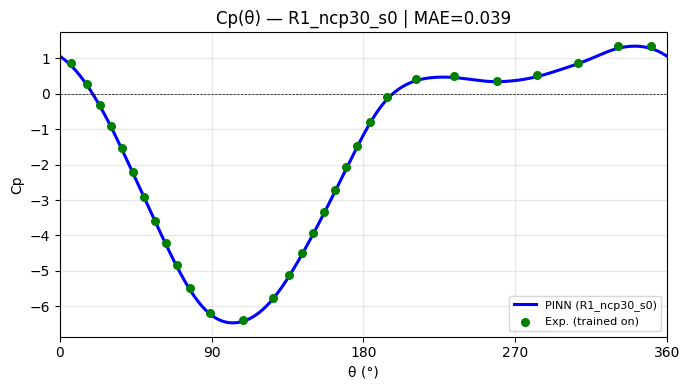

{'cfg': RunConfig(run_id='R1_ncp30_s0', RE=360000.0, ALPHA=2.0, R_IN=0.5, R_OUT=25.0, NCp=30, cp_selection='evenly_spaced_index', cp_theta_explicit=None, mask_sectors=None, hard_constrain_farfield=False, pp_pointwise=False, net_depth=6, net_width=128, EPOCHS=6000, LR=0.0001, LR_DECAY_EPOCH=3000, LR_DECAY_TO=3e-05, TURB_RAMP_START=1000, TURB_RAMP_LEN=1000, N_INT=20000, N_WALL=300, N_FF=150, W_PDE=100.0, W_VWALL=300.0, W_VFF=10.0, W_PP=50.0, W_CP=50, W_TURB=1.0, warm_start_run_id=None, seed=0, notes='recovered notebook, best config, NCp=30'),
 'model': <Functional name=functional, built=True>,
 'history': {'loss': [1672.63330078125,
   20.406898498535156,
   13.634858131408691,
   10.842137336730957,
   1.7125598192214966,
   1.0891274213790894,
   0.7756947875022888,
   0.6312421560287476,
   0.5618411302566528,
   0.5165740847587585,
   0.4692256450653076,
   0.4410586953163147],
  'pde': [0.006947227753698826,
   0.12957334518432617,
   0.09230116009712219,
   0.0495060458779335,
   0

In [5]:
run_case(30)

### 4.2  Train NCp = 8

✓ Run 'R1_ncp8_s0' already completed — skipping training.
R1_ncp8_s0: MAE=0.2606  CL=4.509 (err 23.8%)  CD=1.832 (err 5.0%)


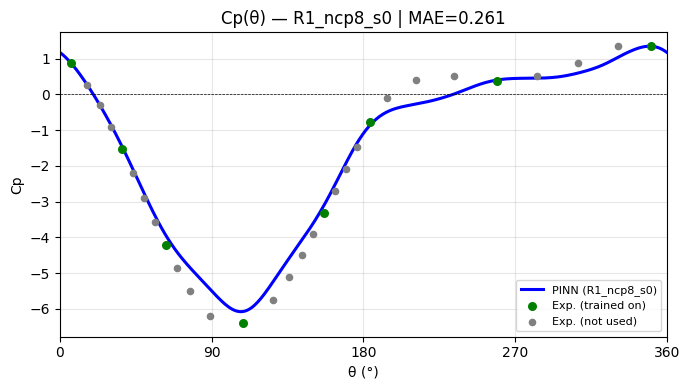

{'cfg': RunConfig(run_id='R1_ncp8_s0', RE=360000.0, ALPHA=2.0, R_IN=0.5, R_OUT=25.0, NCp=8, cp_selection='evenly_spaced_index', cp_theta_explicit=None, mask_sectors=None, hard_constrain_farfield=False, pp_pointwise=False, net_depth=6, net_width=128, EPOCHS=6000, LR=0.0001, LR_DECAY_EPOCH=3000, LR_DECAY_TO=3e-05, TURB_RAMP_START=1000, TURB_RAMP_LEN=1000, N_INT=20000, N_WALL=300, N_FF=150, W_PDE=100.0, W_VWALL=300.0, W_VFF=10.0, W_PP=50.0, W_CP=50, W_TURB=1.0, warm_start_run_id=None, seed=0, notes='recovered notebook, best config, NCp=8'),
 'model': <Functional name=functional, built=True>,
 'history': {'loss': [1783.3587646484375,
   19.62775993347168,
   13.807780265808105,
   47998.26953125,
   25270.8515625,
   1465.0947265625,
   1359.23779296875,
   1348.8990478515625,
   1343.7147216796875,
   1337.107177734375,
   1332.82763671875,
   1328.412841796875],
  'pde': [0.06355081498622894,
   0.12131521850824356,
   0.09205891191959381,
   467.4721984863281,
   234.96270751953125,
   

In [6]:
run_case(8)

### 4.3  Summary and training curves

,run_id,NCp,MAE,RMSE,CL,CL_err_pct,CD,CD_err_pct
0,R1_ncp30_s0,30,0.039181,0.040725,5.131909,13.270296,1.810399,3.763405
1,R1_ncp8_s0,8,0.260578,0.336839,4.508989,23.797699,1.831569,4.976749


Reference (your S2 runs, mean of 3 seeds): NCp=30 MAE 0.042, CL err 13.3%, CD err 3.8% | NCp=8 MAE 0.073, CL err 16.0%, CD err 3.9%
  💾 figure verified: R1_ncp30_s0_training_history.png ✓


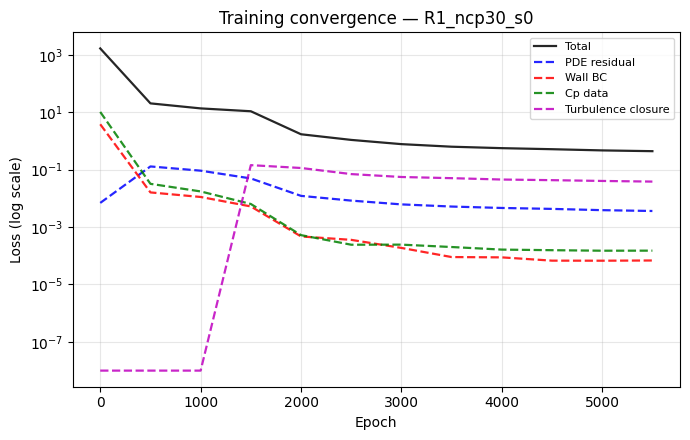

  💾 figure verified: R1_ncp8_s0_training_history.png ✓


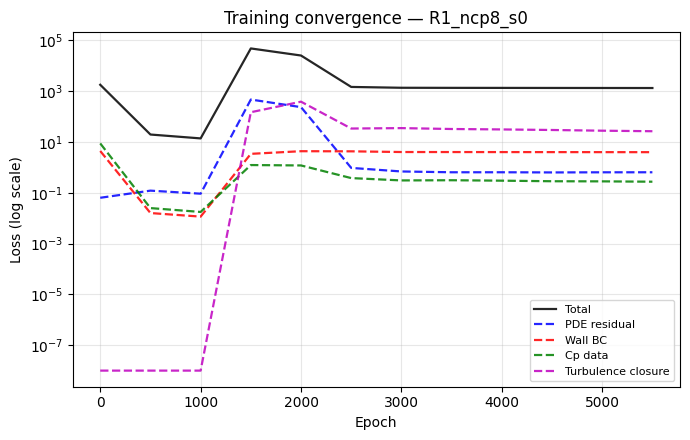

In [7]:
rows = []
for key, r in RUNS.items():
    m = r["metrics"]
    rows.append(dict(run_id=r["cfg"].run_id, NCp=r["cfg"].NCp, MAE=m["MAE"], RMSE=m["RMSE"],
                     CL=m["CL"], CL_err_pct=m["CL_err_pct"], CD=m["CD"], CD_err_pct=m["CD_err_pct"]))
summary = pd.DataFrame(rows)
summary.to_csv(f"{OUT_DIR}/{RUN_TAG}_summary.csv", index=False)
display(summary)
print("Reference (your S2 runs, mean of 3 seeds): NCp=30 MAE 0.042, CL err 13.3%, CD err 3.8% | NCp=8 MAE 0.073, CL err 16.0%, CD err 3.9%")
for key, r in RUNS.items():
    core.plot_training_history(r["history"], r["cfg"].run_id,
                               save_path=f"{OUT_DIR}/{r['cfg'].run_id}_training_history.png",
                               ensure_drive_fn=core.ensure_drive)
    plt.show()

### 4.4  OPTIONAL: load your earlier best run (S2) - this cell can NOT train

Goal: see the earlier, better result in this notebook first, then compare it with the new run `R1`.
Run order: cells 1 to 3 and the set-up cell at the top of Section 4 (the one that defines `data_main`), then THIS cell. Do NOT run 4.1, 4.2 or "Run all": those cells train the new R1 runs.
This cell builds the network, reads the saved weights of the old run and stops. It never calls the training function. The old run is stored as `RUNS["s2_ncp30"]`.
If the files are not found, it prints the files that exist in the old folder so we can fix the name. Nothing is written to the old folder.

In [8]:
OLD_RUNS_DIR = "/content/drive/MyDrive/PINN_Flettner2/runs"      # the folder of your earlier sweeps
OLD_RUN_IDS = {"s2_ncp30": ("S2_ncp30_s0_d6", 30, 0)}            # key : (run_id, NCp, seed)

def load_old_run(key, rid, ncp_, seed_):
    w_path = f"{OLD_RUNS_DIR}/{rid}.weights.h5"
    j_path = f"{OLD_RUNS_DIR}/{rid}_results.json"
    if not os.path.isdir(OLD_RUNS_DIR):
        print(f"FOLDER NOT FOUND: {OLD_RUNS_DIR}  (is Drive mounted? is the folder name right?)"); return
    if not os.path.exists(w_path):
        cands = sorted(f for f in os.listdir(OLD_RUNS_DIR) if f.endswith(".weights.h5") and "ncp30" in f.lower())
        print(f"WEIGHTS NOT FOUND: {w_path}\nncp30 weight files that do exist in that folder ({len(cands)}):")
        for f in cands[:40]: print("   ", f)
        return
    # use the exact configuration stored with the old run when it is available
    stored = {}
    if os.path.exists(j_path):
        stored = json.load(open(j_path)).get("config", {}) or {}
    fields = set(core.RunConfig.__dataclass_fields__)
    kw = {k: v for k, v in stored.items() if k in fields}
    if not kw:
        kw = dict(RE=3.6e5, ALPHA=2.0, NCp=ncp_, cp_selection="evenly_spaced_index", seed=seed_, **BEST_CFG_FIELDS)
    kw["run_id"] = rid
    cfg_old = core.RunConfig(**kw)
    print(f"{rid}: config from {'stored json' if stored else 'BEST_CFG_FIELDS'} | depth={cfg_old.net_depth} width={cfg_old.net_width} "
          f"NCp={cfg_old.NCp} W_CP={cfg_old.W_CP} N_INT={cfg_old.N_INT} EPOCHS={cfg_old.EPOCHS}")
    model = core.build_model(cfg_old)
    model.load_weights(w_path)                     # raises an error if the architecture does not match
    sel = core.select_cp_points(data_main["theta_exp"], data_main["cp_exp"], cfg_old)
    ev_old = core.evaluate(cfg_old, model, data_main, sel, OUT_DIR)      # figures go to the NEW folder
    hist = {}
    if os.path.exists(j_path):
        hist = json.load(open(j_path)).get("history", {})
    RUNS[key] = dict(cfg=cfg_old, model=model, history=hist, metrics=ev_old["metrics"])
    m = ev_old["metrics"]
    print(f"LOADED (no training) {rid}: MAE={m['MAE']:.4f}  CL={m['CL']:.3f} (err {m['CL_err_pct']:.1f}%)  CD={m['CD']:.3f} (err {m['CD_err_pct']:.1f}%)")
    plt.close("all")

for key, (rid, ncp_, seed_) in OLD_RUN_IDS.items():
    load_old_run(key, rid, ncp_, seed_)
print("runs available for diagnosis:", list(RUNS))

S2_ncp30_s0_d6: config from stored json | depth=6 width=128 NCp=30 W_CP=50 N_INT=20000 EPOCHS=6000
LOADED (no training) S2_ncp30_s0_d6: MAE=0.0401  CL=5.129 (err 13.3%)  CD=1.809 (err 3.7%)
runs available for diagnosis: ['ncp30', 'ncp8', 's2_ncp30']


# 5. Compare the PINN with CFD

How to read the numbers
- Velocity is u/U and |u|/U (U = free-stream speed; the PINN is already non-dimensional with U = 1; the CFD velocity is divided by its own U = 5.466 m/s found from the export).
- Pressure is Cp = (p - p_inf) / (0.5 rho U^2). The PINN Cp uses the far-field mean pressure as p_inf, exactly as in training.
- Error = PINN minus CFD, in the same units as the field. The absolute error |PINN - CFD| is shown next to the signed error.

| cell | question it answers |
|---|---|
| 5.2 side-by-side + error maps | where the PINN differs from CFD (signed and absolute) |
| 5.3 line profiles | how big the difference is on the centreline, across the wake, at the wall, at the far field |
| 5.4 wake decay | does Cp and speed recover along the wake as in CFD, and how large is the absolute error along the wake |
| 5.5 error table | mean absolute error and relative L2 by region |
| 5.6 equation residuals | does the PINN satisfy its own equations |
| 5.7 force audit | is the net force the same on every circle around the rotor |
| 5.8 eddy viscosity, total pressure | size of nu_t, and whether pressure and velocity of the PINN belong together |

### 5.1  Settings, CFD loading, helper functions

In [9]:
# ---------------- SETTINGS (edit and re-run the figure cells) ----------------
CMP_RUN        = "ncp30"            # which trained run to diagnose: "ncp30" or "ncp8"
EXTENT         = 4.0                # half-width of the plot window in D (try 2, 4, 8, 25)
NGRID          = 300                # grid resolution of the plots
FIELDS         = ["u", "speed", "pressure"]   # rows to draw; any of "u", "v", "speed", "pressure"

STREAM_ON_CFD   = True              # streamlines drawn on the CFD panel
STREAM_ON_PINN  = True              # streamlines drawn on the PINN panel
STREAM_ON_ERROR = False             # CFD streamlines drawn over the error panel
STREAM_DENSITY  = 1.5
STREAM_COLOR    = "k"
STREAM_LW       = 0.6

ERR_SHOW  = ("signed", "abs")       # error panels to draw: any of "signed", "abs", "percent_of_range"
P_GAUGE    = "farfield"             # "farfield" (same gauge as training) or "best_constant" (remove a constant offset)
CLIP_PCT   = 99                     # error colour range = this percentile of |error|
# -----------------------------------------------------------------------------

from scipy.interpolate import LinearNDInterpolator

# the diagnostics use the functions of the core module as they are
make_input_fn = core.make_input_fn; get_uvp = core.get_uvp; get_ko = core.get_ko; make_turb_constants = core.make_turb_constants

def load_cfd_nodes(csv_path, r_in, r_out):
    """Fluent node export. u_scaled = speed/U_inf. P_scaled = p/(0.5 rho U_inf^2), a Cp-type pressure.
    Velocity components are divided by U_inf, estimated as median(|velocity| / u_scaled)."""
    d = pd.read_csv(csv_path)
    d.columns = [c.strip().replace(chr(0xFEFF), "") for c in d.columns]
    x = d["x-coordinate"].values.astype(np.float64); y = d["y-coordinate"].values.astype(np.float64)
    speed = d["expr:u_scaled"].values.astype(np.float64); cp = d["expr:P_scaled"].values.astype(np.float64)
    has_vel = ("x-velocity" in d.columns) and ("y-velocity" in d.columns)
    if has_vel:
        sp_raw = np.hypot(d["x-velocity"].values, d["y-velocity"].values)
        ok = speed > 0.5
        u_inf = float(np.median(sp_raw[ok] / speed[ok]))
        u = d["x-velocity"].values / u_inf; v = d["y-velocity"].values / u_inf
    else:
        u_inf = np.nan; u = np.full_like(x, np.nan); v = np.full_like(x, np.nan)
        print("NOTE: this csv has no velocity columns. Speed and pressure can be compared; u, v and CFD streamlines cannot.")
    r = np.hypot(x, y)
    keep = (r >= r_in * 0.999) & (r <= r_out * 1.001)
    return dict(x=x[keep], y=y[keep], u=u[keep], v=v[keep], speed=speed[keep], pressure=cp[keep],
                u_inf=u_inf, has_vel=has_vel)

def pinn_eval(model, cfg, x, y, chunk=20000):
    """u, v, p of the PINN at arbitrary points (1-D arrays)."""
    mk = make_input_fn(cfg); out = []
    for i in range(0, len(x), chunk):
        xi = x[i:i+chunk].reshape(-1, 1).astype(np.float32); yi = y[i:i+chunk].reshape(-1, 1).astype(np.float32)
        out.append(get_uvp(model(mk(xi, yi), training=False)).numpy())
    return np.vstack(out)

def pinn_pref(model, cfg, n=256):
    th = np.linspace(0, 2 * np.pi, n, dtype=np.float32)
    o = pinn_eval(model, cfg, cfg.R_OUT * np.cos(th), cfg.R_OUT * np.sin(th))
    return float(o[:, 2].mean())

def pinn_fields(model, cfg, x, y, cfd=None):
    """dict(speed, u, v, pressure) of the PINN at points; pressure is Cp-type, 2(p - p_ref)."""
    o = pinn_eval(model, cfg, x, y)
    pref = pinn_pref(model, cfg)
    cp = 2.0 * (o[:, 2] - pref)
    return dict(u=o[:, 0], v=o[:, 1], speed=np.hypot(o[:, 0], o[:, 1]), pressure=cp)

cfd = load_cfd_nodes(CFD_NODE_CSV, 0.5, 25.0)
print(f"CFD nodes: {len(cfd['x'])} | U_inf (from export) = {cfd['u_inf']:.3f} | velocity columns: {cfd['has_vel']}")
print("CFD far field (r > 24): mean speed = %.4f, mean pressure = %.4f" % (
    cfd["speed"][np.hypot(cfd["x"], cfd["y"]) > 24].mean(), cfd["pressure"][np.hypot(cfd["x"], cfd["y"]) > 24].mean()))

# interpolator over the whole CFD mesh (used for grids and line profiles)
_pts = np.column_stack([cfd["x"], cfd["y"]])
_vals = np.column_stack([cfd["speed"], cfd["u"], cfd["v"], cfd["pressure"]])
_interp = LinearNDInterpolator(_pts, _vals)

def cfd_at(x, y):
    out = _interp(x, y)
    return dict(speed=out[..., 0], u=out[..., 1], v=out[..., 2], pressure=out[..., 3])

def gauge_shift(pred_nodes, name="pressure"):
    """constant to subtract from the PINN pressure when P_GAUGE == 'best_constant'."""
    if P_GAUGE == "best_constant":
        return float(np.mean(pred_nodes[name] - cfd[name]))
    return 0.0

CFD nodes: 14319 | U_inf (from export) = 5.466 | velocity columns: True
CFD far field (r > 24): mean speed = 1.0010, mean pressure = 0.0012


### 5.2  Side-by-side fields and error maps

Columns: CFD, PINN, signed error, absolute error. CFD and PINN panels share the same colour limits. Rows are chosen with `FIELDS`. Streamlines are switched with `STREAM_ON_CFD`, `STREAM_ON_PINN`, `STREAM_ON_ERROR` in 5.1. `EXTENT` sets the window (try 4, 8, 15, 25).

saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_R1_ncp30_s0_fields_ext4.png


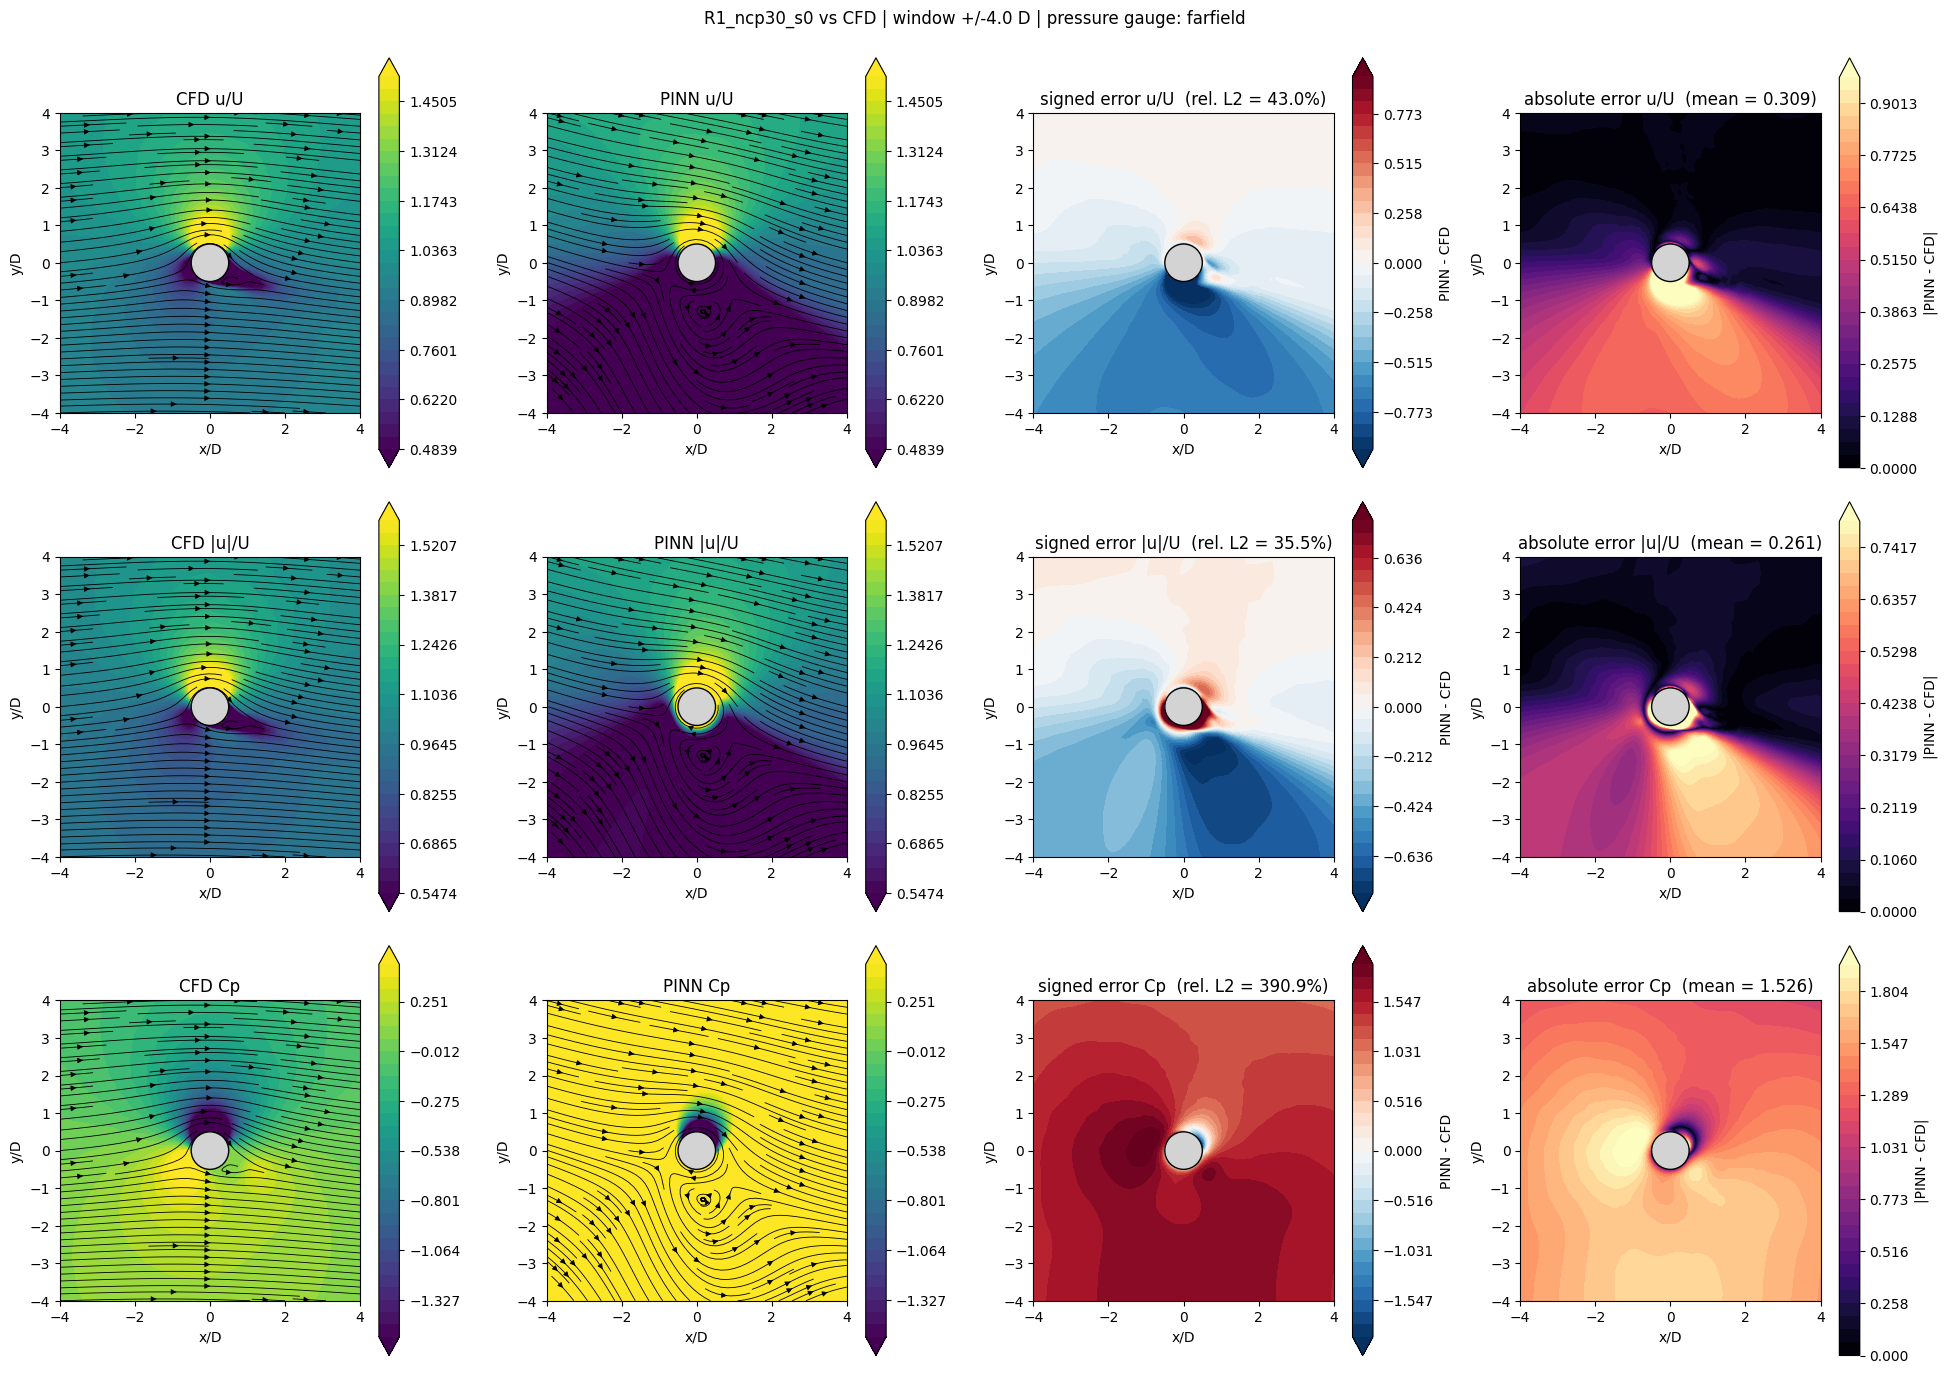

In [10]:
def add_streams(ax, X, Y, U, V, inside):
    Us = np.where(inside | ~np.isfinite(U), 0.0, U); Vs = np.where(inside | ~np.isfinite(V), 0.0, V)
    ax.streamplot(X[0, :], Y[:, 0], Us, Vs, density=STREAM_DENSITY, color=STREAM_COLOR, linewidth=STREAM_LW, arrowsize=0.8)

def compare_figure(run_key=CMP_RUN, save=True):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]
    xg = np.linspace(-EXTENT, EXTENT, NGRID); X, Y = np.meshgrid(xg, xg)
    inside = np.hypot(X, Y) < cfg.R_IN
    ref = cfd_at(X, Y)
    pf = pinn_fields(model, cfg, X.ravel(), Y.ravel())
    pred = {k: v.reshape(X.shape) for k, v in pf.items()}
    pred["pressure"] = pred["pressure"] - gauge_shift(pinn_fields(model, cfg, cfd["x"], cfd["y"]))

    fields = [f for f in FIELDS if cfd["has_vel"] or f in ("speed", "pressure")]
    ncol = 2 + len(ERR_SHOW)
    fig, axes = plt.subplots(len(fields), ncol, figsize=(4.9 * ncol, 4.6 * len(fields)), squeeze=False)
    labels = dict(speed="|u|/U", u="u/U", v="v/U", pressure="Cp")
    for row, name in enumerate(fields):
        a, b = ref[name].copy(), pred[name].copy()
        a[inside] = np.nan; b[inside] = np.nan
        ok = np.isfinite(a)
        lo, hi = np.percentile(a[ok], [1, 99]); levels = np.linspace(lo, hi, 31)
        err = np.where(ok, b - a, np.nan)
        c0 = axes[row, 0].contourf(X, Y, np.ma.masked_invalid(a), levels=levels, cmap="viridis", extend="both")
        c1 = axes[row, 1].contourf(X, Y, np.ma.masked_invalid(b), levels=levels, cmap="viridis", extend="both")
        fig.colorbar(c0, ax=axes[row, 0]); fig.colorbar(c1, ax=axes[row, 1])
        axes[row, 0].set_title(f"CFD {labels[name]}"); axes[row, 1].set_title(f"PINN {labels[name]}")
        mae = np.nanmean(np.abs(err)); rl2 = np.sqrt(np.nanmean(err ** 2)) / np.sqrt(np.nanmean(a ** 2))
        for j, mode in enumerate(ERR_SHOW):
            ax = axes[row, 2 + j]
            if mode == "abs":
                ep = np.abs(err); em = max(np.nanpercentile(ep, CLIP_PCT), 1e-9)
                c = ax.contourf(X, Y, np.ma.masked_invalid(ep), levels=np.linspace(0, em, 31), cmap="magma", extend="max")
                fig.colorbar(c, ax=ax, label="|PINN - CFD|"); ax.set_title(f"absolute error {labels[name]}  (mean = {mae:.3f})")
            elif mode == "percent_of_range":
                ep = 100.0 * err / (hi - lo); em = max(np.nanpercentile(np.abs(ep), CLIP_PCT), 1e-9)
                c = ax.contourf(X, Y, np.ma.masked_invalid(ep), levels=np.linspace(-em, em, 31), cmap="RdBu_r", extend="both")
                fig.colorbar(c, ax=ax, label="% of CFD range"); ax.set_title(f"error, % of CFD range {labels[name]}")
            else:
                em = max(np.nanpercentile(np.abs(err), CLIP_PCT), 1e-9)
                c = ax.contourf(X, Y, np.ma.masked_invalid(err), levels=np.linspace(-em, em, 31), cmap="RdBu_r", extend="both")
                fig.colorbar(c, ax=ax, label="PINN - CFD"); ax.set_title(f"signed error {labels[name]}  (rel. L2 = {rl2*100:.1f}%)")
        if cfd["has_vel"]:
            if STREAM_ON_CFD:   add_streams(axes[row, 0], X, Y, ref["u"], ref["v"], inside)
            if STREAM_ON_ERROR:
                for j in range(len(ERR_SHOW)): add_streams(axes[row, 2 + j], X, Y, ref["u"], ref["v"], inside)
        if STREAM_ON_PINN: add_streams(axes[row, 1], X, Y, pred["u"], pred["v"], inside)
        for ax in axes[row]:
            ax.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray", edgecolor="k", zorder=5))
            ax.set_xlim(-EXTENT, EXTENT); ax.set_ylim(-EXTENT, EXTENT); ax.set_aspect("equal"); ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
    fig.suptitle(f"{cfg.run_id} vs CFD | window +/-{EXTENT} D | pressure gauge: {P_GAUGE}", y=1.0)
    plt.tight_layout()
    if save:
        path = f"{OUT_DIR}/diag_{cfg.run_id}_fields_ext{EXTENT:g}.png"; fig.savefig(path, dpi=200, bbox_inches="tight"); print("saved:", path)
    return fig

compare_figure(); plt.show()

### 5.3  Line profiles

Wake centreline (y = 0), wake cross-sections, wall check and far-field check. Solid lines are CFD, dashed lines are the PINN. Speed is |u|/U, pressure is Cp.

saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_R1_ncp30_s0_profiles.png


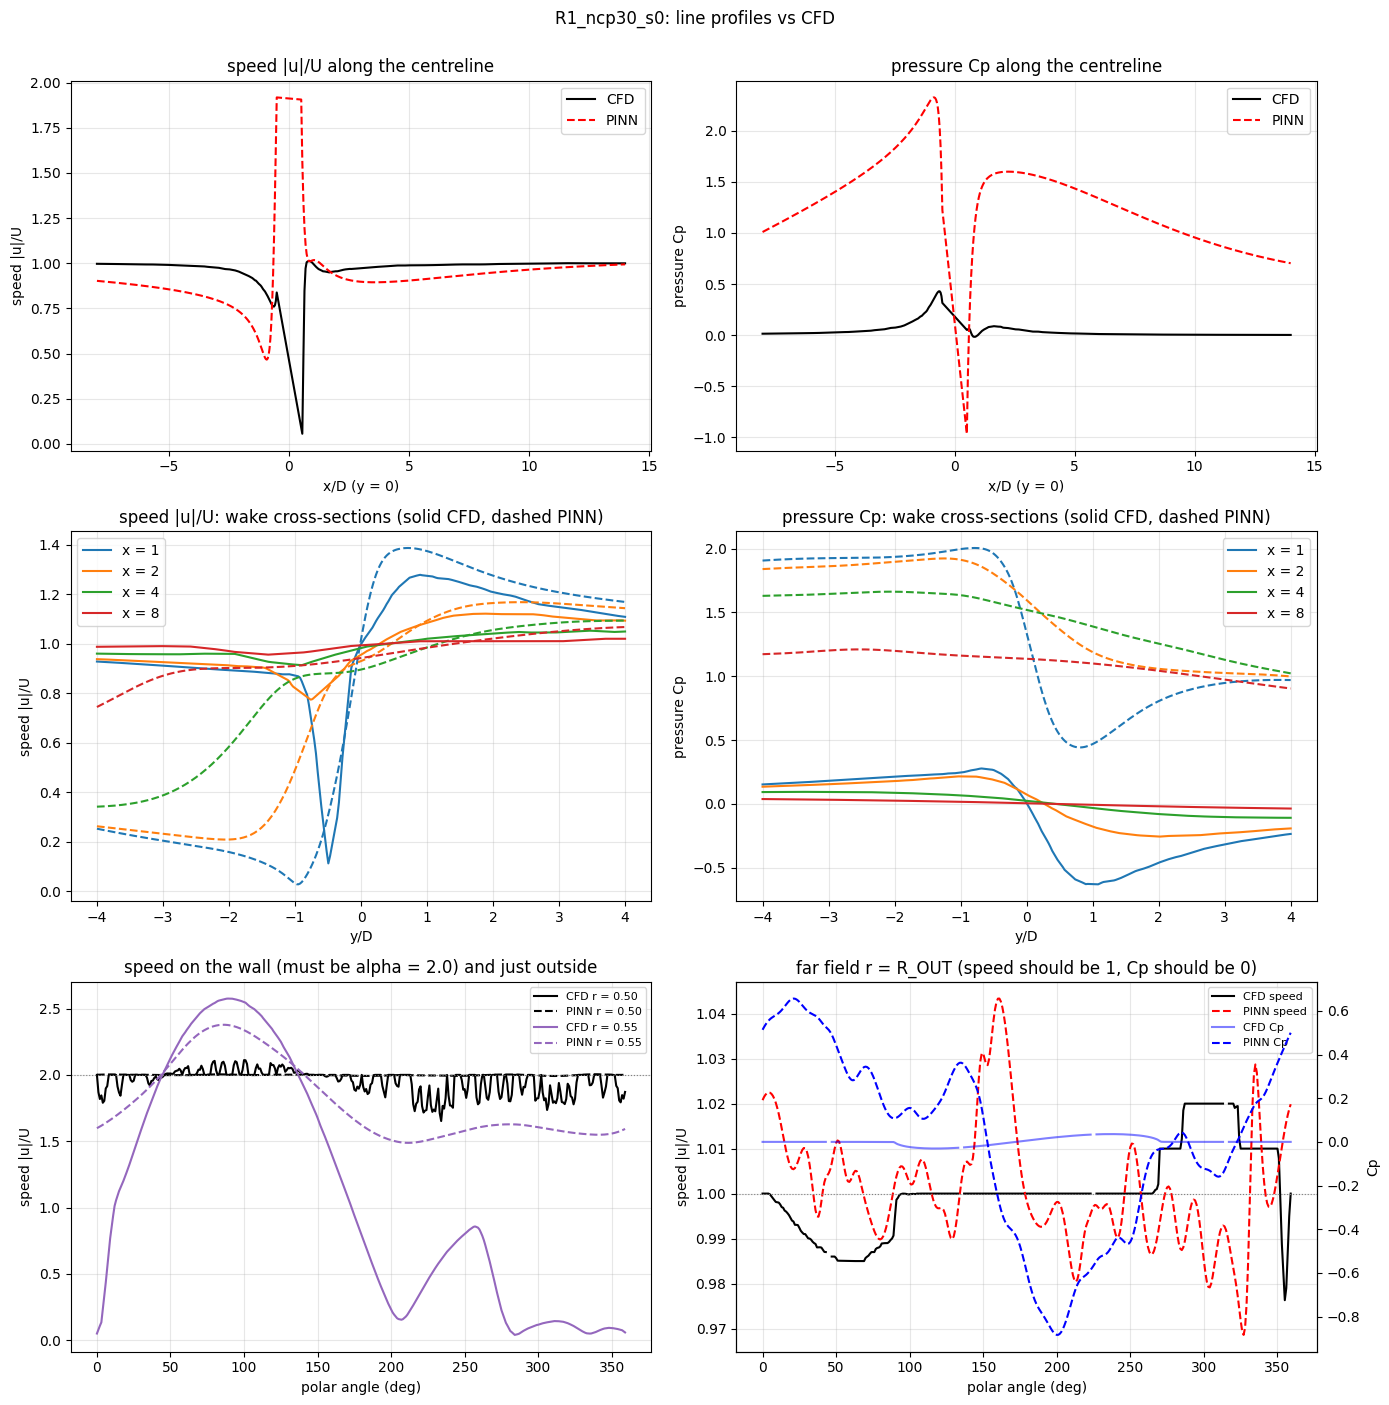

saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_R1_ncp30_s0_profiles.png


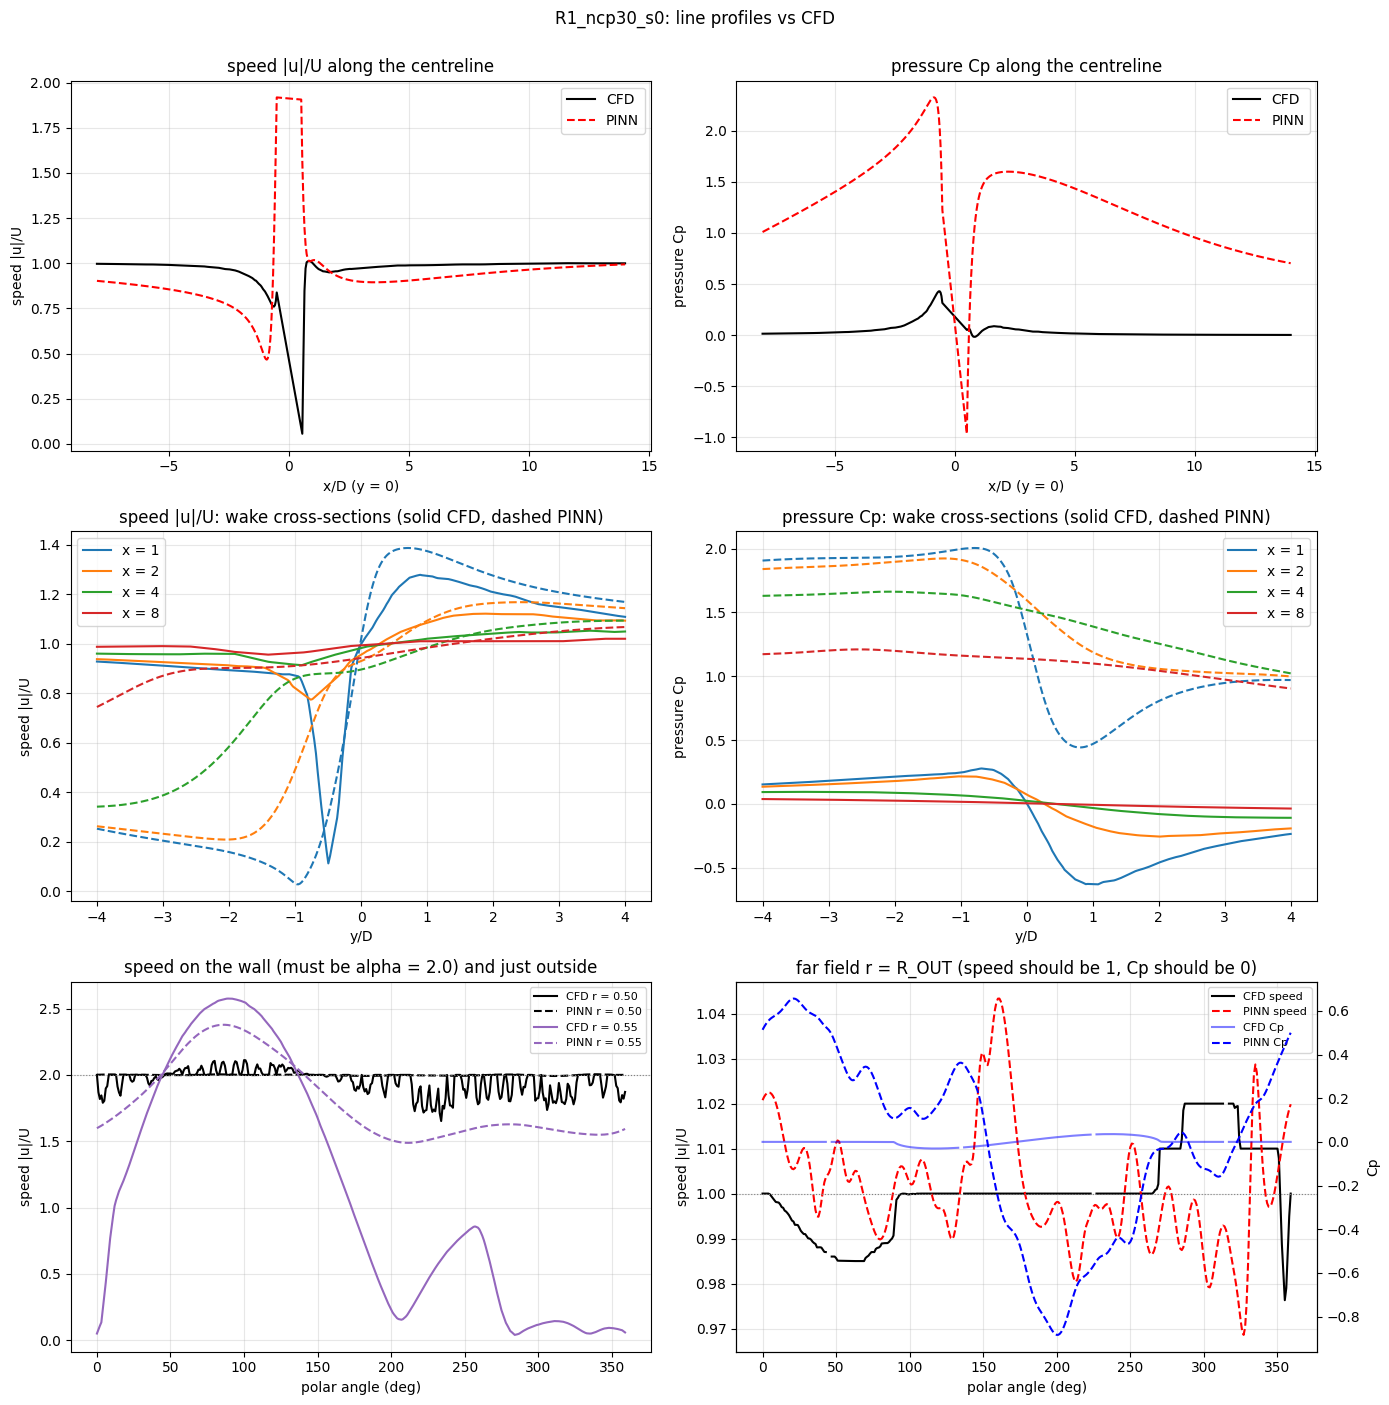

In [11]:
def profiles_figure(run_key=CMP_RUN, save=True):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]
    pn_nodes = pinn_fields(model, cfg, cfd["x"], cfd["y"]); shift = gauge_shift(pn_nodes)
    def P(x, y):
        f = pinn_fields(model, cfg, np.ravel(x), np.ravel(y)); f["pressure"] = f["pressure"] - shift; return f

    fig, ax = plt.subplots(3, 2, figsize=(14, 14))
    # (a), (b) along y = 0
    xs = np.concatenate([np.linspace(-8, -cfg.R_IN * 1.02, 200), np.linspace(cfg.R_IN * 1.02, 14, 300)])
    ys = np.zeros_like(xs); c = cfd_at(xs, ys); p = P(xs, ys)
    for k, (name, lab) in enumerate([("speed", "speed |u|/U"), ("pressure", "pressure Cp")]):
        a_ = ax[0, k]; a_.plot(xs, c[name], "k-", label="CFD"); a_.plot(xs, p[name], "r--", label="PINN")
        a_.set_xlabel("x/D (y = 0)"); a_.set_ylabel(lab); a_.set_title(f"{lab} along the centreline"); a_.grid(alpha=.3); a_.legend()
    # (c), (d) wake cross-sections
    cols = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    for k, (name, lab) in enumerate([("speed", "speed |u|/U"), ("pressure", "pressure Cp")]):
        a_ = ax[1, k]
        for xc, col in zip([1, 2, 4, 8], cols):
            yy = np.linspace(-4, 4, 300); xx = np.full_like(yy, float(xc))
            a_.plot(yy, cfd_at(xx, yy)[name], "-", color=col, label=f"x = {xc}")
            a_.plot(yy, P(xx, yy)[name], "--", color=col)
        a_.set_xlabel("y/D"); a_.set_ylabel(lab); a_.set_title(f"{lab}: wake cross-sections (solid CFD, dashed PINN)"); a_.grid(alpha=.3); a_.legend()
    # (e) wall and near-wall ring
    th = np.linspace(0, 2 * np.pi, 361)[:-1]
    for rr, col in [(cfg.R_IN, "k"), (cfg.R_IN * 1.1, "tab:purple")]:
        xr, yr = rr * np.cos(th), rr * np.sin(th)
        ax[2, 0].plot(np.degrees(th), cfd_at(xr, yr)["speed"], "-", color=col, label=f"CFD r = {rr:.2f}")
        ax[2, 0].plot(np.degrees(th), P(xr, yr)["speed"], "--", color=col, label=f"PINN r = {rr:.2f}")
    ax[2, 0].axhline(2.0, color="gray", lw=.8, ls=":"); ax[2, 0].set_xlabel("polar angle (deg)"); ax[2, 0].set_ylabel("speed |u|/U")
    ax[2, 0].set_title("speed on the wall (must be alpha = 2.0) and just outside"); ax[2, 0].grid(alpha=.3); ax[2, 0].legend(fontsize=8)
    # (f) far-field ring
    xr, yr = cfg.R_OUT * 0.999 * np.cos(th), cfg.R_OUT * 0.999 * np.sin(th)
    ax[2, 1].plot(np.degrees(th), cfd_at(xr, yr)["speed"], "k-", label="CFD speed"); ax[2, 1].plot(np.degrees(th), P(xr, yr)["speed"], "r--", label="PINN speed")
    ax2 = ax[2, 1].twinx()
    ax2.plot(np.degrees(th), cfd_at(xr, yr)["pressure"], "b-", alpha=.5, label="CFD Cp"); ax2.plot(np.degrees(th), P(xr, yr)["pressure"], "b--", label="PINN Cp")
    ax[2, 1].axhline(1.0, color="gray", lw=.8, ls=":"); ax[2, 1].set_xlabel("polar angle (deg)"); ax[2, 1].set_ylabel("speed |u|/U"); ax2.set_ylabel("Cp")
    ax[2, 1].set_title("far field r = R_OUT (speed should be 1, Cp should be 0)"); ax[2, 1].grid(alpha=.3)
    h1, l1 = ax[2, 1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax[2, 1].legend(h1 + h2, l1 + l2, fontsize=8)
    fig.suptitle(f"{cfg.run_id}: line profiles vs CFD", y=1.0); plt.tight_layout()
    if save:
        path = f"{OUT_DIR}/diag_{cfg.run_id}_profiles.png"; fig.savefig(path, dpi=200, bbox_inches="tight"); print("saved:", path)
    return fig

profiles_figure(); plt.show()

profiles_figure(); plt.show()

### 5.4  Wake decay: speed, Cp and total pressure along the wake

The wake of a lifting rotor is not on y = 0. For every x the CFD wake centre is taken as the point of lowest speed (searched between y = -6 and y = 2), and CFD and PINN are both read along that same curve. Top row: |u|/U, Cp and total-pressure coefficient H = Cp + |u|^2 - 1 along the wake (H is 0 in undisturbed flow and cannot be positive downstream of a body in a steady flow). Bottom row: absolute errors of |u|/U and Cp, and the path of the wake centre. If the PINN Cp does not return to 0 as CFD does, you see it here as a number.

saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_R1_ncp30_s0_wake_decay.png


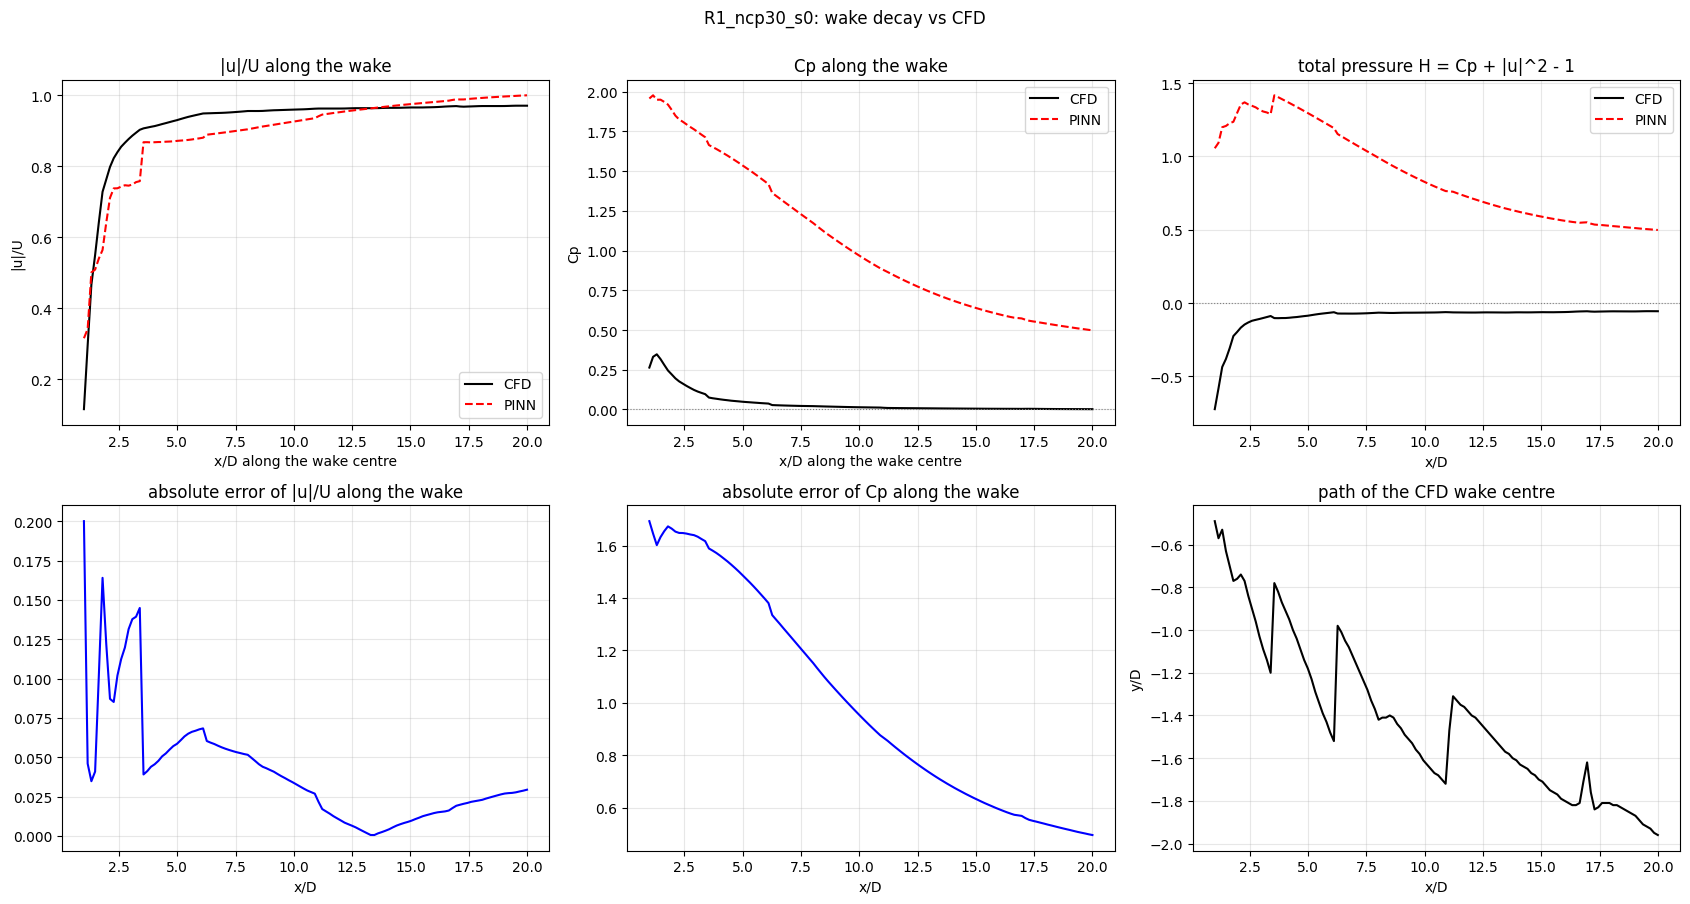

,x range (D),mean |err| |u|/U,mean |err| Cp,PINN Cp mean,CFD Cp mean
0,1-3,0.104,1.649,1.876,0.227
1,3-6,0.069,1.522,1.583,0.062
2,6-10,0.049,1.153,1.174,0.021
3,10-20,0.016,0.663,0.669,0.006


In [12]:
def wake_decay_figure(run_key=CMP_RUN, x_max=20.0, save=True):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]
    shift = gauge_shift(pinn_fields(model, cfg, cfd["x"], cfd["y"]))
    xs = np.linspace(1.0, x_max, 120); yy = np.linspace(-6.0, 2.0, 801)
    yc = np.array([yy[np.nanargmin(cfd_at(np.full_like(yy, x), yy)["speed"])] for x in xs])
    c = cfd_at(xs, yc); p = pinn_fields(model, cfg, xs, yc); p["pressure"] = p["pressure"] - shift
    Hc = c["pressure"] + c["speed"] ** 2 - 1.0; Hp = p["pressure"] + p["speed"] ** 2 - 1.0
    fig, ax = plt.subplots(2, 3, figsize=(17, 9))
    for a, nm, lab in [(ax[0, 0], "speed", "|u|/U"), (ax[0, 1], "pressure", "Cp")]:
        a.plot(xs, c[nm], "k-", label="CFD"); a.plot(xs, p[nm], "r--", label="PINN"); a.set_xlabel("x/D along the wake centre"); a.set_ylabel(lab)
        a.set_title(f"{lab} along the wake"); a.grid(alpha=.3); a.legend()
    ax[0, 1].axhline(0.0, color="gray", lw=.8, ls=":")
    ax[0, 2].plot(xs, Hc, "k-", label="CFD"); ax[0, 2].plot(xs, Hp, "r--", label="PINN"); ax[0, 2].axhline(0, color="gray", lw=.8, ls=":")
    ax[0, 2].set_title("total pressure H = Cp + |u|^2 - 1"); ax[0, 2].set_xlabel("x/D"); ax[0, 2].grid(alpha=.3); ax[0, 2].legend()
    ax[1, 0].plot(xs, np.abs(p["speed"] - c["speed"]), "b-"); ax[1, 0].set_title("absolute error of |u|/U along the wake"); ax[1, 0].set_xlabel("x/D"); ax[1, 0].grid(alpha=.3)
    ax[1, 1].plot(xs, np.abs(p["pressure"] - c["pressure"]), "b-"); ax[1, 1].set_title("absolute error of Cp along the wake"); ax[1, 1].set_xlabel("x/D"); ax[1, 1].grid(alpha=.3)
    ax[1, 2].plot(xs, yc, "k-"); ax[1, 2].set_title("path of the CFD wake centre"); ax[1, 2].set_xlabel("x/D"); ax[1, 2].set_ylabel("y/D"); ax[1, 2].grid(alpha=.3)
    fig.suptitle(f"{cfg.run_id}: wake decay vs CFD", y=1.0); plt.tight_layout()
    bins = [(1, 3), (3, 6), (6, 10), (10, 20.01)]
    sel = lambda lo, hi: (xs >= lo) & (xs < hi)
    tab = pd.DataFrame({"x range (D)": [f"{lo}-{int(hi)}" for lo, hi in bins],
        "mean |err| |u|/U": [np.mean(np.abs(p["speed"] - c["speed"])[sel(lo, hi)]) for lo, hi in bins],
        "mean |err| Cp":    [np.mean(np.abs(p["pressure"] - c["pressure"])[sel(lo, hi)]) for lo, hi in bins],
        "PINN Cp mean":     [np.mean(p["pressure"][sel(lo, hi)]) for lo, hi in bins],
        "CFD Cp mean":      [np.mean(c["pressure"][sel(lo, hi)]) for lo, hi in bins]})
    if save:
        path = f"{OUT_DIR}/diag_{cfg.run_id}_wake_decay.png"; fig.savefig(path, dpi=200, bbox_inches="tight"); print("saved:", path)
        tab.to_csv(f"{OUT_DIR}/diag_{cfg.run_id}_wake_decay.csv", index=False)
    return fig, tab

_fig, _tab = wake_decay_figure(); plt.show()
display(_tab.round(3))

### 5.5  Error table by region

`MAE` is the mean absolute error (same units as u/U or Cp), `relL2` the relative L2 error, `bias` the mean of PINN minus CFD. A bias far from zero with a small relL2 means an offset, not a wrong pattern. Evaluated on the CFD nodes, no interpolation.

In [13]:
def region_table(run_key=CMP_RUN, save=True):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]
    pr = pinn_fields(model, cfg, cfd["x"], cfd["y"]); pr["pressure"] = pr["pressure"] - gauge_shift(pr)
    x, y = cfd["x"], cfd["y"]; rad = np.hypot(x, y)
    regions = {
        "whole domain":              np.ones(len(x), bool),
        "near wall r<1":             rad < 1.0,
        "near wall r<2":             rad < 2.0,
        "upstream x<-1, r<6":        (x < -1.0) & (rad < 6.0),
        "wake x 1-8, |y|<1.5":       (x >= 1.0) & (x <= 8.0) & (np.abs(y) < 1.5),
        "wide wake x 1-15, |y|<3":   (x >= 1.0) & (x <= 15.0) & (np.abs(y) < 3.0),
        "far field r>10":            rad > 10.0,
    }
    names = ["speed", "pressure"] + (["u", "v"] if cfd["has_vel"] else [])
    rows = []
    for rn, m in regions.items():
        row = {"region": rn, "n_nodes": int(m.sum())}
        for n in names:
            d = pr[n][m] - cfd[n][m]
            row[f"{n}_MAE"] = float(np.mean(np.abs(d)))
            row[f"{n}_relL2"] = float(np.sqrt(np.mean(d ** 2)) / (np.sqrt(np.mean(cfd[n][m] ** 2)) + 1e-12))
            row[f"{n}_bias"] = float(np.mean(d))
        rows.append(row)
    df = pd.DataFrame(rows)
    # boundary condition checks
    th = np.linspace(0, 2 * np.pi, 360, endpoint=False)
    wall = pinn_fields(model, cfg, cfg.R_IN * np.cos(th), cfg.R_IN * np.sin(th))
    ff = pinn_fields(model, cfg, cfg.R_OUT * np.cos(th), cfg.R_OUT * np.sin(th))
    print(f"PINN wall speed:  mean = {wall['speed'].mean():.3f}, min = {wall['speed'].min():.3f}, max = {wall['speed'].max():.3f}   (target {cfg.ALPHA:.2f})")
    print(f"PINN far-field:   mean speed = {ff['speed'].mean():.3f} (std {ff['speed'].std():.3f}),  Cp mean = {ff['pressure'].mean():.4f} (std {ff['pressure'].std():.4f})   (targets 1 and 0)")
    if save:
        path = f"{OUT_DIR}/diag_{cfg.run_id}_region_errors.csv"; df.to_csv(path, index=False); print("saved:", path)
    return df

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
display(region_table().round(3))

PINN wall speed:  mean = 1.999, min = 1.992, max = 2.005   (target 2.00)
PINN far-field:   mean speed = 1.002 (std 0.013),  Cp mean = -0.0020 (std 0.4189)   (targets 1 and 0)
saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_R1_ncp30_s0_region_errors.csv


,region,n_nodes,speed_MAE,speed_relL2,speed_bias,pressure_MAE,pressure_relL2,pressure_bias,u_MAE,u_relL2,u_bias,v_MAE,v_relL2,v_bias
0,whole domain,14319,0.306,0.444,0.158,0.829,0.677,0.647,0.327,0.545,-0.287,0.267,1.000,-0.059
1,near wall r<1,6347,0.553,0.556,0.452,1.095,0.556,0.798,0.591,0.727,-0.534,0.481,0.979,-0.055
2,near wall r<2,6652,0.542,0.551,0.420,1.117,0.578,0.834,0.580,0.720,-0.525,0.469,0.979,-0.062
3,"upstream x<-1, r<6",240,0.240,0.290,-0.218,1.591,8.545,1.591,0.299,0.390,-0.289,0.352,2.343,-0.352
4,"wake x 1-8, |y|<1.5",164,0.100,0.194,-0.066,1.429,7.511,1.429,0.129,0.217,-0.128,0.150,0.789,-0.145
5,"wide wake x 1-15, |y|<3",463,0.099,0.207,-0.075,1.176,8.829,1.176,0.108,0.219,-0.101,0.084,0.822,-0.049
6,far field r>10,6423,0.077,0.121,-0.047,0.446,18.814,0.334,0.080,0.130,-0.052,0.070,3.485,-0.035


### 5.6  Does the PINN satisfy its own equations?

Top row: the PINN's own continuity and momentum residuals (computed exactly as in training, with the SST eddy viscosity the network predicts) and the predicted eddy-viscosity ratio nu_t/nu (shown as log10 of 1 + ratio). Bottom row: the speed error and the pressure error from 5.2, placed under the residuals so you can compare where they are large. Residuals are shown as log10 of the magnitude. Residuals are measured on the PINN only; the CFD field is not tested against the PINN equations because the Fluent export has no k or omega.

median |momentum residual|: wake region = 2.62e-02, rest of window (r>3) = 2.44e-02
median |continuity residual|: wake region = 9.24e-03, rest of window (r>3) = 1.57e-02
saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_R1_ncp30_s0_residuals_ext4.png


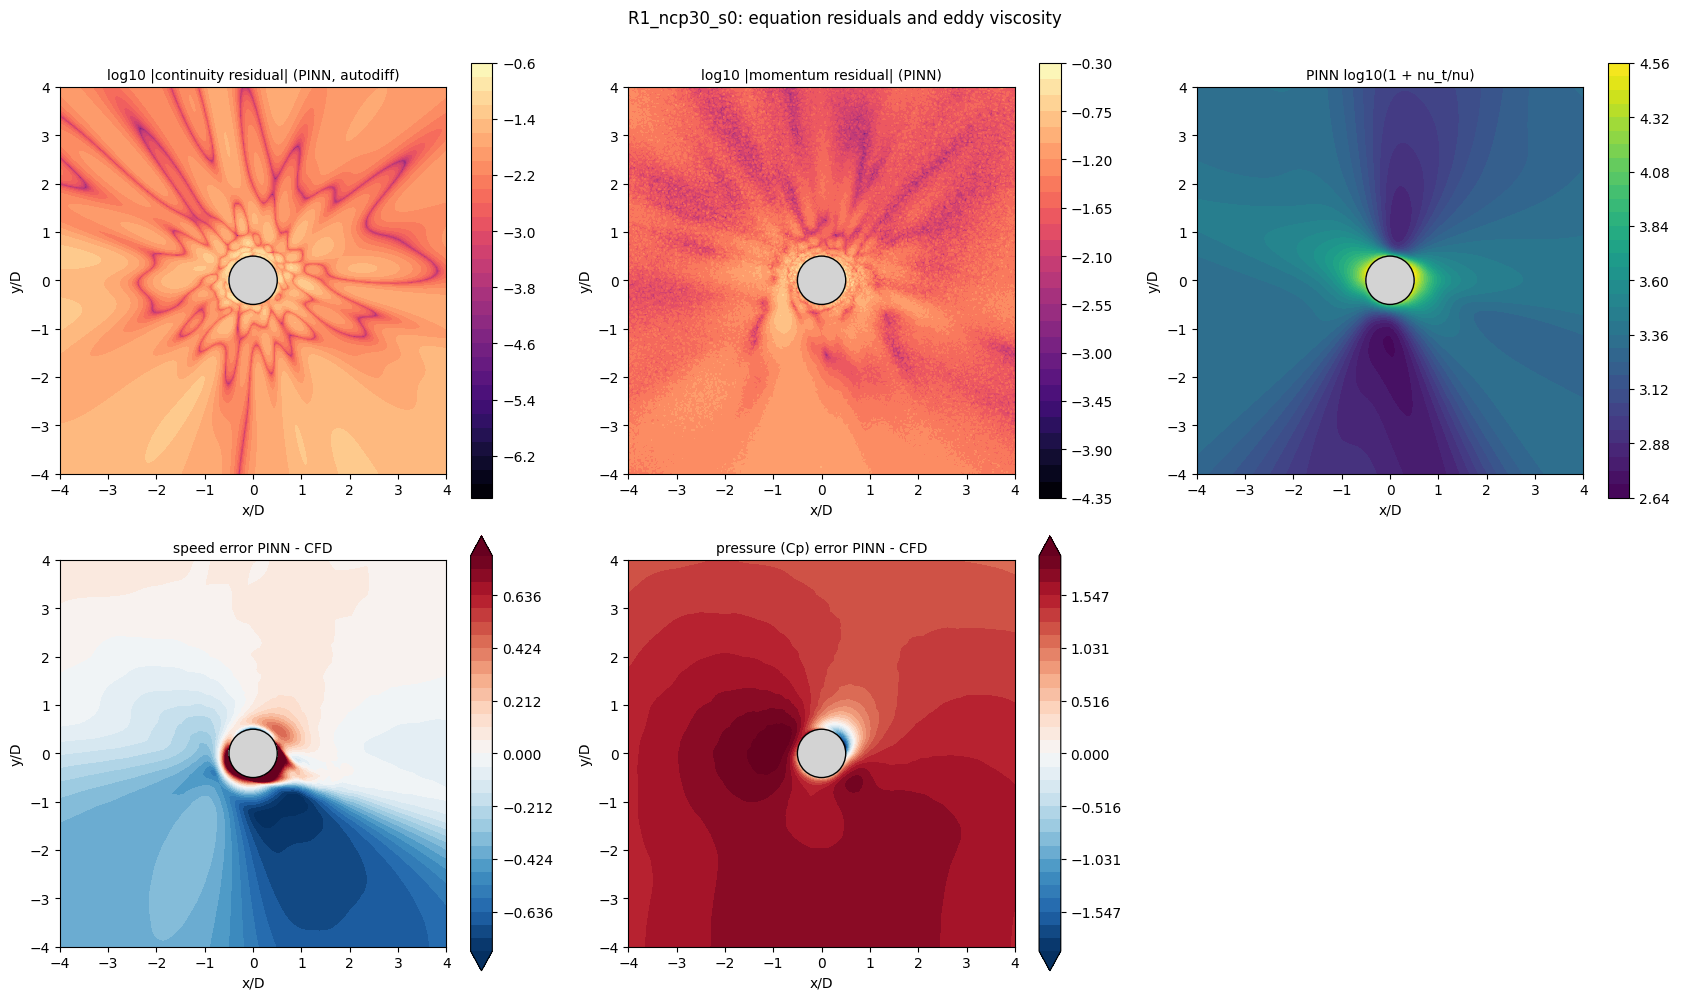

In [14]:
def pinn_residuals(model, cfg, x, y, eps=1e-3, chunk=10000):
    """continuity, momentum-x, momentum-y residuals and nu_t/nu, same formulas as the training loop (full turbulence)."""
    mk = make_input_fn(cfg); C = make_turb_constants(cfg)
    rc, rx, ry, nut = [], [], [], []
    for i in range(0, len(x), chunk):
        xi = x[i:i+chunk].reshape(-1, 1).astype(np.float32); yi = y[i:i+chunk].reshape(-1, 1).astype(np.float32)
        xy = tf.Variable(mk(xi, yi), trainable=False, dtype=tf.float32)
        with tf.GradientTape(persistent=True) as t:
            t.watch(xy)
            out = model(xy, training=False); uvp = get_uvp(out); ko = get_ko(out)
            u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
        du = t.gradient(u, xy); dv = t.gradient(v, xy); dp = t.gradient(p, xy); del t
        n = xi.shape[0]
        dX = tf.constant(np.hstack([np.full((n, 1), eps), np.zeros((n, 1)), np.zeros((n, 1))]).astype(np.float32))
        dY = tf.constant(np.hstack([np.zeros((n, 1)), np.full((n, 1), eps), np.zeros((n, 1))]).astype(np.float32))
        uxp = get_uvp(model(xy + dX, training=False)); uxm = get_uvp(model(xy - dX, training=False))
        uyp = get_uvp(model(xy + dY, training=False)); uym = get_uvp(model(xy - dY, training=False))
        ie2 = 1.0 / eps ** 2
        d2u = (uxp[:, 0:1] - 2 * u + uxm[:, 0:1]) * ie2 + (uyp[:, 0:1] - 2 * u + uym[:, 0:1]) * ie2
        d2v = (uxp[:, 1:2] - 2 * v + uxm[:, 1:2]) * ie2 + (uyp[:, 1:2] - 2 * v + uym[:, 1:2]) * ie2
        k = ko[:, 0:1] + C["EPS"]; om = ko[:, 1:2] + C["EPS"]
        nu_t = tf.clip_by_value(k / (om + C["EPS"]), 0., .1); nu_eff = C["NU"] + nu_t
        rc.append((du[:, 0:1] + dv[:, 1:2]).numpy())
        rx.append((u * du[:, 0:1] + v * du[:, 1:2] + dp[:, 0:1] - nu_eff * d2u).numpy())
        ry.append((u * dv[:, 0:1] + v * dv[:, 1:2] + dp[:, 1:2] - nu_eff * d2v).numpy())
        nut.append((nu_t / C["NU"]).numpy())
    f = lambda a: np.vstack(a).ravel()
    return f(rc), f(rx), f(ry), f(nut)

def residual_figure(run_key=CMP_RUN, save=True):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]
    xg = np.linspace(-EXTENT, EXTENT, NGRID); X, Y = np.meshgrid(xg, xg); inside = np.hypot(X, Y) < cfg.R_IN
    rc, rx, ry, nut = [a.reshape(X.shape) for a in pinn_residuals(model, cfg, X.ravel(), Y.ravel())]
    pf = pinn_fields(model, cfg, X.ravel(), Y.ravel())
    shift = gauge_shift(pinn_fields(model, cfg, cfd["x"], cfd["y"]))
    ref = cfd_at(X, Y)
    lg = lambda a: np.where(inside, np.nan, np.log10(np.abs(a) + 1e-12))
    mom = np.hypot(rx, ry)
    fig, ax = plt.subplots(2, 3, figsize=(17, 10))
    panels = [(ax[0, 0], lg(rc), "log10 |continuity residual| (PINN, autodiff)", "magma"),
              (ax[0, 1], lg(mom), "log10 |momentum residual| (PINN)", "magma"),
              (ax[0, 2], np.where(inside, np.nan, np.log10(nut + 1.0)), "PINN log10(1 + nu_t/nu)", "viridis")]
    sp_err = np.where(inside, np.nan, pf["speed"].reshape(X.shape) - ref["speed"])
    p_err = np.where(inside, np.nan, pf["pressure"].reshape(X.shape) - shift - ref["pressure"])
    panels += [(ax[1, 0], sp_err, "speed error PINN - CFD", "RdBu_r"),
               (ax[1, 1], p_err, "pressure (Cp) error PINN - CFD", "RdBu_r")]
    for a, f, title, cm in panels:
        f = np.ma.masked_invalid(f)
        if cm == "RdBu_r":
            m_ = np.nanpercentile(np.abs(f.filled(np.nan)), 99); c = a.contourf(X, Y, f, levels=np.linspace(-m_, m_, 31), cmap=cm, extend="both")
        else:
            c = a.contourf(X, Y, f, levels=30, cmap=cm)
        fig.colorbar(c, ax=a); a.set_title(title, fontsize=10)
        a.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray", edgecolor="k", zorder=5))
        a.set_xlim(-EXTENT, EXTENT); a.set_ylim(-EXTENT, EXTENT); a.set_aspect("equal"); a.set_xlabel("x/D"); a.set_ylabel("y/D")
    ax[1, 2].axis("off")
    fig.suptitle(f"{cfg.run_id}: equation residuals and eddy viscosity", y=1.0); plt.tight_layout()
    # numbers in the wake region
    wake = (X >= 1) & (X <= 8) & (np.abs(Y) < 1.5) & ~inside
    far = (np.hypot(X, Y) > 3) & ~inside
    print(f"median |momentum residual|: wake region = {np.median(mom[wake]):.2e}, rest of window (r>3) = {np.median(mom[far]):.2e}")
    print(f"median |continuity residual|: wake region = {np.median(np.abs(rc[wake])):.2e}, rest of window (r>3) = {np.median(np.abs(rc[far])):.2e}")
    if save:
        path = f"{OUT_DIR}/diag_{cfg.run_id}_residuals_ext{EXTENT:g}.png"; fig.savefig(path, dpi=200, bbox_inches="tight"); print("saved:", path)
    return fig

residual_figure(); plt.show()

### 5.7  Force audit: is the CFD itself consistent with the wind tunnel?

The net force on the rotor can be computed on any circle of radius R around it from the momentum theorem (force on body = minus the integral over the circle of momentum flux + pressure - viscous stress). In a steady, correct flow the answer must not depend on R, and at R = 0.5 it must equal the force from the wall pressure. Three curves are drawn against R:

- CFD circle: velocity and pressure interpolated from the Fluent export (viscous stress neglected; it is tiny away from the wall).
- PINN circle: same formula on the PINN field, without eddy stress.
- PINN circle + eddy stress: same, with the modelled stress nu_eff x (grad u + grad u transposed).

Horizontal lines: the wall-integral values of the PINN run and the wind-tunnel values. Reading it: if the CFD curve is flat but far below the wind-tunnel drag, the CFD and the experiment are not the same physical flow, so CFD cannot be used as the truth for the drag-carrying wake. If the PINN curve changes strongly with R, the PINN field is not momentum-consistent (it does not satisfy its own equations in integral form).

Wind tunnel (Bordogna):  CL = 5.917   CD = 1.745
PINN wall integral:      CL = 5.132   CD = 1.810
saved: diag_R1_ncp30_s0_force_audit.(png/csv)


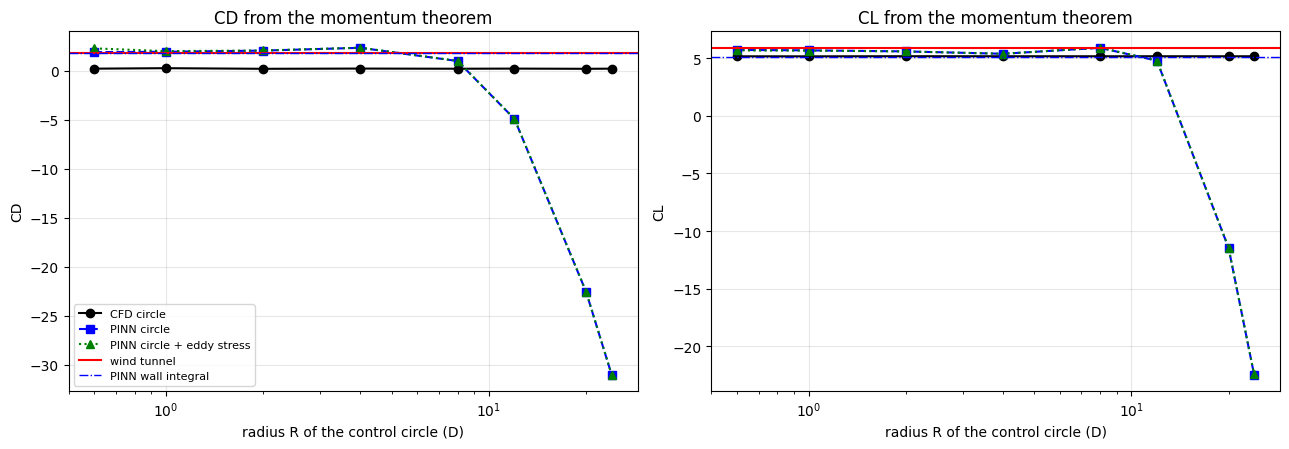

,R,CFD_CD,CFD_CL,PINN_CD,PINN_CL,PINN_eddy_CD,PINN_eddy_CL
0,0.6,0.199,5.163,1.882,5.716,2.265,5.671
1,1.0,0.246,5.160,1.922,5.681,1.985,5.654
2,2.0,0.184,5.171,2.038,5.588,2.051,5.585
3,4.0,0.207,5.167,2.325,5.382,2.337,5.383
4,8.0,0.191,5.166,0.976,5.899,0.995,5.911
5,12.0,0.204,5.168,-4.931,4.780,-4.910,4.799
6,20.0,0.184,5.165,-22.558,-11.464,-22.535,-11.437
7,24.0,0.198,5.167,-31.020,-22.460,-30.998,-22.430


In [15]:
def _ring_points(Rc, n):
    th = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return th, np.cos(th), np.sin(th), Rc * np.cos(th), Rc * np.sin(th), 2 * np.pi * Rc / n

def cfd_ring_forces(Rc, n=1440):
    th, nx, ny, x, y, ds = _ring_points(Rc, n)
    f = cfd_at(x, y); u, v, p = f["u"], f["v"], f["pressure"] / 2.0       # p = Cp/2 (rho = U = 1)
    un = u * nx + v * ny
    Fx = -np.nansum(u * un + p * nx) * ds
    Fy = -np.nansum(v * un + p * ny) * ds
    return Fx / 0.5, Fy / 0.5                                               # (CD, CL), D = 1

def pinn_ring_forces(model, cfg, Rc, n=1440):
    th, nx, ny, x, y, ds = _ring_points(Rc, n)
    mk = make_input_fn(cfg); C = make_turb_constants(cfg)
    xy = tf.Variable(mk(x.reshape(-1, 1).astype(np.float32), y.reshape(-1, 1).astype(np.float32)), trainable=False, dtype=tf.float32)
    with tf.GradientTape(persistent=True) as t:
        t.watch(xy)
        out = model(xy, training=False); uvp = get_uvp(out); ko = get_ko(out)
        u_, v_ = uvp[:, 0:1], uvp[:, 1:2]
    du = t.gradient(u_, xy).numpy(); dv = t.gradient(v_, xy).numpy(); del t
    u = uvp[:, 0].numpy(); v = uvp[:, 1].numpy()
    p = uvp[:, 2].numpy() - pinn_pref(model, cfg)
    k = ko[:, 0:1] + C["EPS"]; om = ko[:, 1:2] + C["EPS"]
    nut_cap = getattr(cfg, "nut_max", 0.1)
    nu_eff = (C["NU"] + tf.clip_by_value(k / (om + C["EPS"]), 0., nut_cap)).numpy().ravel()
    un = u * nx + v * ny
    ax = -np.sum(u * un + p * nx) * ds; ay = -np.sum(v * un + p * ny) * ds
    tx = nu_eff * (2 * du[:, 0] * nx + (du[:, 1] + dv[:, 0]) * ny)
    ty = nu_eff * ((du[:, 1] + dv[:, 0]) * nx + 2 * dv[:, 1] * ny)
    bx = ax + np.sum(tx) * ds; by = ay + np.sum(ty) * ds                   # + tau.n term
    return (ax / 0.5, ay / 0.5), (bx / 0.5, by / 0.5)

def force_audit(run_key=CMP_RUN, radii=(0.6, 1, 2, 4, 8, 12, 20, 24), save=True):
    r = RUNS[run_key]; cfg, model, m = r["cfg"], r["model"], r["metrics"]
    rows = []
    for Rc in radii:
        c_cd, c_cl = cfd_ring_forces(Rc)
        (p_cd, p_cl), (e_cd, e_cl) = pinn_ring_forces(model, cfg, Rc)
        rows.append(dict(R=Rc, CFD_CD=c_cd, CFD_CL=c_cl, PINN_CD=p_cd, PINN_CL=p_cl, PINN_eddy_CD=e_cd, PINN_eddy_CL=e_cl))
    df = pd.DataFrame(rows)
    print(f"Wind tunnel (Bordogna):  CL = {data['cl_ref']:.3f}   CD = {data['cd_ref']:.3f}")
    print(f"PINN wall integral:      CL = {m['CL']:.3f}   CD = {m['CD']:.3f}")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    for a, nm, ref_val, wall_val in [(ax[0], "CD", data["cd_ref"], m["CD"]), (ax[1], "CL", data["cl_ref"], m["CL"])]:
        a.semilogx(df["R"], df["CFD_" + nm], "ko-", label="CFD circle")
        a.semilogx(df["R"], df["PINN_" + nm], "bs--", label="PINN circle")
        a.semilogx(df["R"], df["PINN_eddy_" + nm], "g^:", label="PINN circle + eddy stress")
        a.axhline(ref_val, color="r", lw=1.5, label="wind tunnel")
        a.axhline(wall_val, color="b", lw=1.0, ls="-.", label="PINN wall integral")
        a.set_xlabel("radius R of the control circle (D)"); a.set_ylabel(nm); a.set_title(nm + " from the momentum theorem"); a.grid(alpha=0.3)
    ax[0].legend(fontsize=8)
    plt.tight_layout()
    if save:
        df.to_csv(f"{OUT_DIR}/diag_{cfg.run_id}_force_audit.csv", index=False)
        fig.savefig(f"{OUT_DIR}/diag_{cfg.run_id}_force_audit.png", dpi=200, bbox_inches="tight"); print("saved: diag_" + cfg.run_id + "_force_audit.(png/csv)")
    return df

_df_force = force_audit(); plt.show()
display(_df_force.round(3))

### 5.8  Eddy viscosity and total pressure

Eddy-viscosity table: nu_t/nu of the PINN at the CFD node locations, by region. `cap share` is the fraction of nodes sitting at the clip limit (the network is asking for more eddy viscosity than allowed). `Re_eff` is 1/(nu + nu_t), the effective Reynolds number the momentum equation sees there. At the true Re = 3.6e5, values of Re_eff of order 10 in the wake mean the PINN is solving an almost viscous creeping flow in the wake, which would give a smeared, too-wide wake.

Total-pressure figure: H = Cp + |u|^2 - 1. It is zero in the undisturbed flow and can only be negative downstream of a body in steady flow (the body removes total pressure). Large positive H far from the rotor, or positive H anywhere in the wake, is not physical and shows the pressure and velocity of the PINN do not belong together.

molecular Re = 3.6e+05; eddy-viscosity cap = 0.1 (ratio 36000)


,region,n,nut/nu median,nut/nu p90,nut/nu p99,cap share,Re_eff median
0,all nodes,14319,3719.068115,16578.216797,29817.449219,0.000,96.772
1,wall layer r<0.6,3068,13699.214844,27044.576172,34069.214844,0.002,26.277
2,near r<2,6652,8188.262207,23027.169922,32170.322266,0.001,43.960
3,"wake x 1-8, |y|<1.5",164,2489.956055,3108.595947,4559.356934,0.000,144.523
4,"lower half y<-1, r<10",608,1730.380005,2344.996094,2746.179932,0.000,207.928
5,far r>10,6423,3403.408936,4356.956055,5145.369141,0.000,105.745


fraction of window (r>3) with H > +0.1:  CFD = 0.000   PINN = 1.000
saved total pressure figure


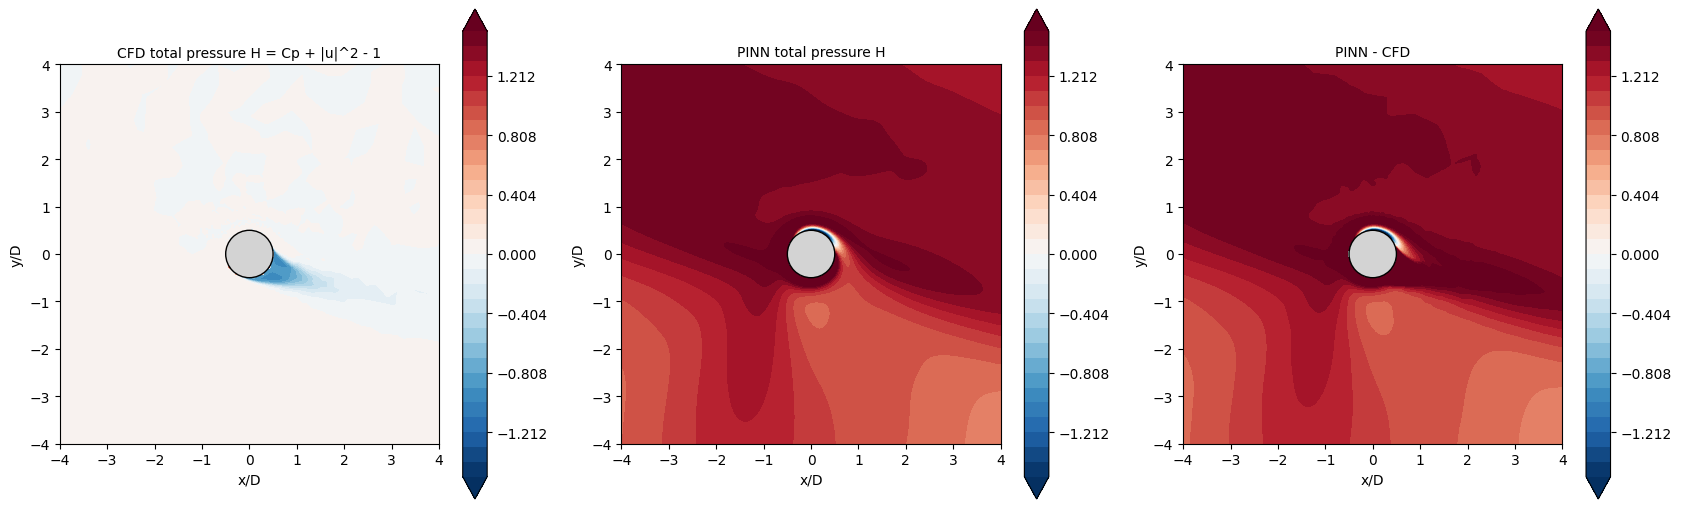

In [16]:
def pinn_ko(model, cfg, x, y, chunk=20000):
    mk = make_input_fn(cfg); out = []
    for i in range(0, len(x), chunk):
        xi = x[i:i+chunk].reshape(-1, 1).astype(np.float32); yi = y[i:i+chunk].reshape(-1, 1).astype(np.float32)
        out.append(get_ko(model(mk(xi, yi), training=False)).numpy())
    return np.vstack(out)

def nut_audit(run_key=CMP_RUN):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]; C = make_turb_constants(cfg)
    x, y = cfd["x"], cfd["y"]; rad = np.hypot(x, y)
    ko = pinn_ko(model, cfg, x, y)
    k = ko[:, 0] + C["EPS"]; om = ko[:, 1] + C["EPS"]
    cap = getattr(cfg, "nut_max", 0.1)
    nut = np.clip(k / (om + C["EPS"]), 0.0, cap)
    ratio = nut / C["NU"]
    regions = {"all nodes": np.ones(len(x), bool), "wall layer r<0.6": rad < 0.6, "near r<2": rad < 2.0,
               "wake x 1-8, |y|<1.5": (x >= 1) & (x <= 8) & (np.abs(y) < 1.5),
               "lower half y<-1, r<10": (y < -1) & (rad < 10), "far r>10": rad > 10}
    rows = []
    for nm, mk_ in regions.items():
        q = ratio[mk_]
        rows.append({"region": nm, "n": int(mk_.sum()), "nut/nu median": np.median(q), "nut/nu p90": np.percentile(q, 90),
                     "nut/nu p99": np.percentile(q, 99), "cap share": float(np.mean(nut[mk_] >= 0.999 * cap)),
                     "Re_eff median": float(np.median(1.0 / (C["NU"] + nut[mk_])))})
    print(f"molecular Re = {1.0 / C['NU']:.3g}; eddy-viscosity cap = {cap} (ratio {cap / C['NU']:.0f})")
    return pd.DataFrame(rows)

def total_pressure_figure(run_key=CMP_RUN, save=True):
    r = RUNS[run_key]; cfg, model = r["cfg"], r["model"]
    xg = np.linspace(-EXTENT, EXTENT, NGRID); X, Y = np.meshgrid(xg, xg); inside = np.hypot(X, Y) < cfg.R_IN
    ref = cfd_at(X, Y)
    pf = pinn_fields(model, cfg, X.ravel(), Y.ravel())
    shift = gauge_shift(pinn_fields(model, cfg, cfd["x"], cfd["y"]))
    Hc = ref["pressure"] + ref["speed"] ** 2 - 1.0
    Hp = (pf["pressure"] - shift).reshape(X.shape) + pf["speed"].reshape(X.shape) ** 2 - 1.0
    Hc = np.where(inside, np.nan, Hc); Hp = np.where(inside, np.nan, Hp)
    m_ = np.nanpercentile(np.abs(np.concatenate([Hc[np.isfinite(Hc)], Hp[np.isfinite(Hp)]])), 99)
    lv = np.linspace(-m_, m_, 31)
    fig, ax = plt.subplots(1, 3, figsize=(17, 5.2))
    for a, f, t_ in [(ax[0], Hc, "CFD total pressure H = Cp + |u|^2 - 1"), (ax[1], Hp, "PINN total pressure H"), (ax[2], Hp - Hc, "PINN - CFD")]:
        c = a.contourf(X, Y, np.ma.masked_invalid(f), levels=lv, cmap="RdBu_r", extend="both"); fig.colorbar(c, ax=a); a.set_title(t_, fontsize=10)
        a.add_patch(plt.Circle((0, 0), cfg.R_IN, facecolor="lightgray", edgecolor="k", zorder=5))
        a.set_xlim(-EXTENT, EXTENT); a.set_ylim(-EXTENT, EXTENT); a.set_aspect("equal"); a.set_xlabel("x/D"); a.set_ylabel("y/D")
    plt.tight_layout()
    far = (np.hypot(X, Y) > 3) & ~inside
    print(f"fraction of window (r>3) with H > +0.1:  CFD = {np.nanmean(Hc[far] > 0.1):.3f}   PINN = {np.nanmean(Hp[far] > 0.1):.3f}")
    if save:
        fig.savefig(f"{OUT_DIR}/diag_{cfg.run_id}_total_pressure_ext{EXTENT:g}.png", dpi=200, bbox_inches="tight"); print("saved total pressure figure")
    return fig

display(nut_audit().round(3))
total_pressure_figure(); plt.show()

### 5.9  Diagnose the other run

Change `CMP_RUN` in 5.1 to `"ncp8"`, or call `diagnose("ncp8")` below, to repeat 5.2 to 5.8 for the NCp = 8 run. All figures and tables are saved to `OUT_DIR` with the run id in the file name.

In [17]:
def diagnose(run_key):
    compare_figure(run_key); plt.show()
    profiles_figure(run_key); plt.show()
    f_, t_ = wake_decay_figure(run_key); plt.show(); display(t_.round(3))
    display(region_table(run_key).round(3))
    residual_figure(run_key); plt.show()
    force_audit(run_key); plt.show()
    display(nut_audit(run_key).round(3))
    total_pressure_figure(run_key); plt.show()

# diagnose("ncp8")

### 5.10  Old run (S2) against the new run (R1), same CFD, same units

Both runs are scored on the same CFD nodes with the same Cp = 2 (p - p_ref) scaling, so the numbers are directly comparable.
Look at the column `ratio` = R1 / S2. A value near 1.0 means the two runs are equally good in that region. A value above 1.0 means R1 is worse.
Run this after cell 4.4. The figure of the old run is `compare_figure("s2_ncp30")`.

PINN wall speed:  mean = 2.000, min = 1.989, max = 2.008   (target 2.00)
PINN far-field:   mean speed = 1.000 (std 0.014),  Cp mean = -0.0016 (std 0.4422)   (targets 1 and 0)
PINN wall speed:  mean = 1.999, min = 1.992, max = 2.005   (target 2.00)
PINN far-field:   mean speed = 1.002 (std 0.013),  Cp mean = -0.0020 (std 0.4189)   (targets 1 and 0)


S2                                                          R1                                             ratio                                        
                        n_nodes speed_MAE speed_relL2 pressure_MAE pressure_relL2 speed_MAE speed_relL2 pressure_MAE pressure_relL2 speed_MAE speed_relL2 pressure_MAE pressure_relL2
region                                                                                                                                                                               
whole domain              14319     0.299       0.439        0.823          0.665     0.306       0.444        0.829          0.677     1.025       1.010        1.007          1.018
near wall r<1              6347     0.544       0.550        1.073          0.545     0.553       0.556        1.095          0.556     1.018       1.011        1.020          1.020
near wall r<2              6652     0.533       0.545        1.093          0.566     0.542       0.551        1.117          0.578     1.017       1.011        1.022          1.022
upstream x<-1, r<6          240     0.225       0.282        1.554          8.323     0.240       0.290        1.591          8.545     1.065       1.030        1.024          1.027
wake x 1-8, |y|<1.5         164     0.104       0.207        1.352          7.110     0.100       0.194        1.429          7.511     0.968       0.933        1.057          1.056
wide wake x 1-15, |y|<3     463     0.102       0.222        1.106          8.337     0.099       0.207        1.176          8.829     0.965       0.934        1.064          1.059
far field r>10             6423     0.073       0.122        0.461         18.891     0.077       0.121        0.446         18.814     1.058       0.993        0.968          0.996

saved: /content/drive/MyDrive/PINN_Flettner2/recovered_runs/diag_S2_ncp30_s0_d6_fields_ext4.png


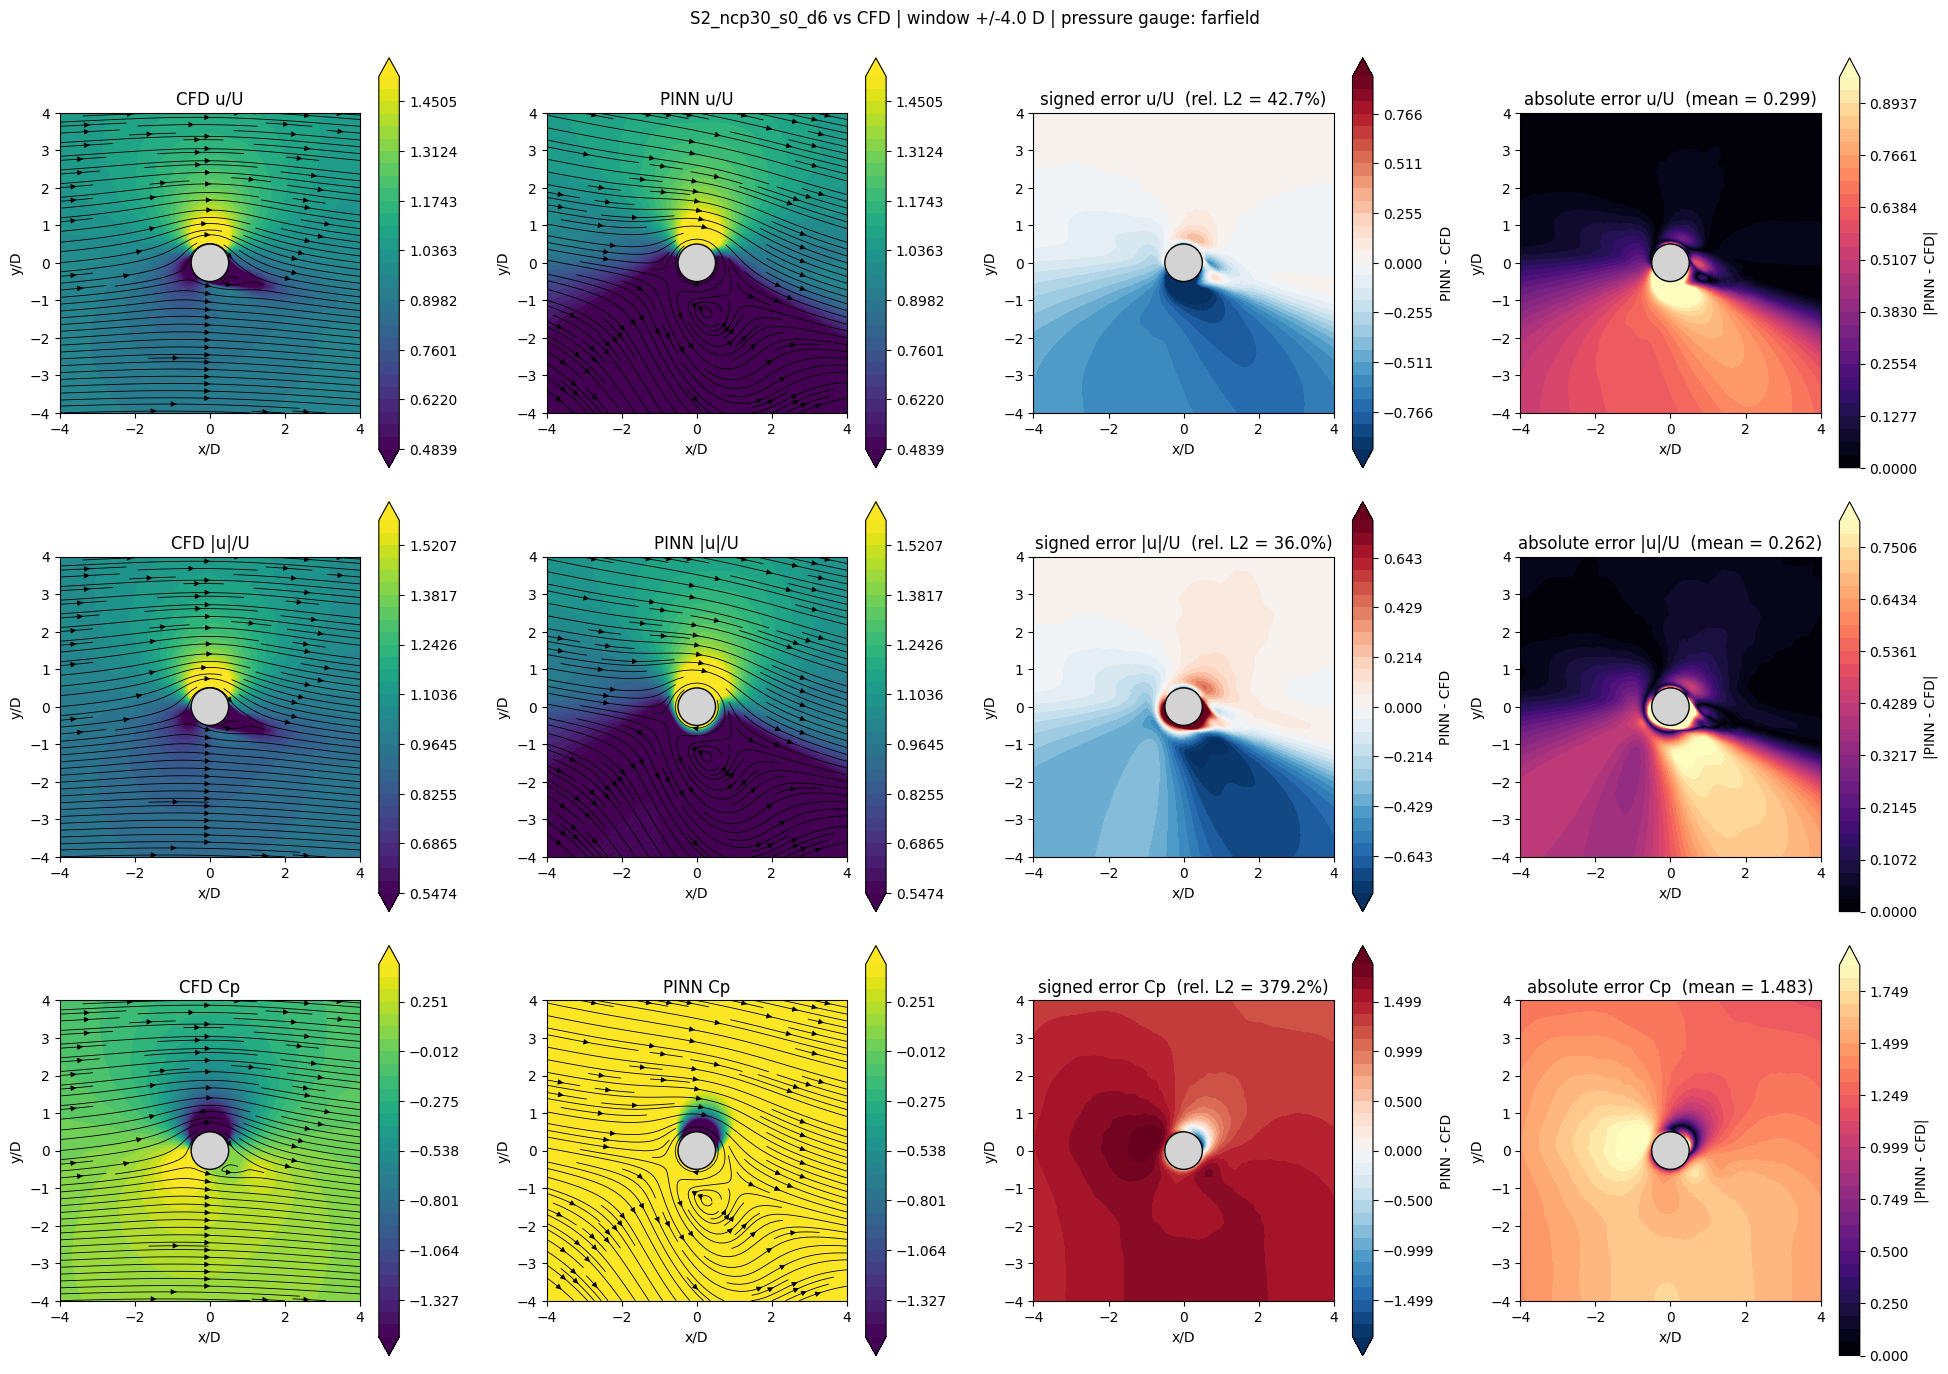

In [18]:
if "s2_ncp30" in RUNS and "ncp30" in RUNS:
    a = region_table("s2_ncp30", save=False).set_index("region")
    b = region_table("ncp30", save=False).set_index("region")
    cols = ["n_nodes", "speed_MAE", "speed_relL2", "pressure_MAE", "pressure_relL2"]
    out = pd.concat({"S2": a[cols], "R1": b[cols[1:]]}, axis=1)
    for c in cols[1:]:
        out[("ratio", c)] = b[c] / a[c]
    display(out.round(3))
    out.to_csv(f"{OUT_DIR}/S2_vs_R1_region_table.csv")
    compare_figure("s2_ncp30"); plt.show()
else:
    print("Need both RUNS['s2_ncp30'] (cell 4.4) and RUNS['ncp30'] (cell 4.1).")